# BÀI THI CUỐI KỲ: KHOA HỌC DỮ LIỆU
**Họ và tên:** Lê Thị Hải Yến  
**MSSV:** CH330184  
**Đề tài:** Dự đoán khả năng vỡ nợ của khách hàng bằng Machine Learning

# Tổng quan quy trình nghiên cứu

Bài làm được tổ chức thành **sáu giai đoạn lớn** để bảo đảm tách biệt rõ giữa phát triển mô hình, hiệu chỉnh xác suất và đánh giá cuối cùng:

| Giai đoạn | Nội dung chính | Vai trò |
|---|---|---|
| **1. Hiểu và đánh giá dữ liệu** | Khảo sát dữ liệu, kiểm tra chất lượng, phân tích nhãn và EDA | Hiểu cấu trúc dữ liệu, mất cân bằng lớp và các yếu tố liên quan đến vỡ nợ |
| **2. Xử lý feature và thiết kế mẫu** | Làm sạch, phân loại biến, chia Train–Validation–Test, PSI và VIF | Hạn chế leakage và bảo đảm quy trình đánh giá khách quan |
| **3. Xây dựng baseline và challenger** | WOE Logistic làm baseline; Random Forest và XGBoost làm challenger | So sánh mô hình dễ giải thích với các mô hình phi tuyến |
| **4. Tinh chỉnh siêu tham số** | `RandomizedSearchCV` trên tập Train với cross-validation | Tối ưu khả năng phân biệt rủi ro mà không sử dụng Validation/Test |
| **5. Calibration và lựa chọn mô hình** | Calibration trên Validation, lựa chọn threshold và champion | Làm xác suất gần tỷ lệ default thực tế hơn và lựa chọn mô hình theo mục tiêu nghiệp vụ |
| **6. Đánh giá cuối và khuyến nghị** | Đánh giá một lần trên Test, PSI score, SHAP và đề xuất triển khai | Đo hiệu quả ngoài mẫu và chuyển kết quả thành hành động ngân hàng |

## Nguyên tắc sử dụng ba tập dữ liệu

- **Train:** fit mô hình, WOE/IV và chạy `RandomizedSearchCV` bằng cross-validation.
- **Validation:** so sánh mô hình sau tuning, calibration xác suất và lựa chọn threshold.
- **Test:** chỉ sử dụng một lần ở cuối để báo cáo kết quả cuối cùng.
- Mọi bước imputation, encoding, WOE binning và one-hot encoding đều được fit trong pipeline để hạn chế data leakage.

# A. Hiểu và đánh giá dữ liệu

## Bước 1: Nạp dữ liệu & khảo sát tổng quan

In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline
sns.set_style('whitegrid')
sns.set_palette('deep')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 11
plt.rcParams['axes.titlesize'] = 13
plt.rcParams['axes.titleweight'] = 'bold'

RANDOM_STATE = 42

df = pd.read_csv('credit_risk_dataset.csv')
print('Kích thước:', df.shape)
df.head()


Kích thước: (32581, 12)


,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4


In [29]:
df.info()
df.describe().round(2)


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32581 entries, 0 to 32580
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   person_age                  32581 non-null  int64  
 1   person_income               32581 non-null  int64  
 2   person_home_ownership       32581 non-null  object 
 3   person_emp_length           31686 non-null  float64
 4   loan_intent                 32581 non-null  object 
 5   loan_grade                  32581 non-null  object 
 6   loan_amnt                   32581 non-null  int64  
 7   loan_int_rate               29465 non-null  float64
 8   loan_status                 32581 non-null  int64  
 9   loan_percent_income         32581 non-null  float64
 10  cb_person_default_on_file   32581 non-null  object 
 11  cb_person_cred_hist_length  32581 non-null  int64  
dtypes: float64(3), int64(5), object(4)
memory usage: 3.0+ MB


,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_cred_hist_length
count,32581.00,32581.00,31686.00,32581.00,29465.00,32581.00,32581.00,32581.00
mean,27.73,66074.85,4.79,9589.37,11.01,0.22,0.17,5.80
std,6.35,61983.12,4.14,6322.09,3.24,0.41,0.11,4.06
min,20.00,4000.00,0.00,500.00,5.42,0.00,0.00,2.00
25%,23.00,38500.00,2.00,5000.00,7.90,0.00,0.09,3.00
50%,26.00,55000.00,4.00,8000.00,10.99,0.00,0.15,4.00
75%,30.00,79200.00,7.00,12200.00,13.47,0.00,0.23,8.00
max,144.00,6000000.00,123.00,35000.00,23.22,1.00,0.83,30.00


In [30]:
# Tổng quan chất lượng dữ liệu
print('Số dòng trùng lặp:', df.duplicated().sum())

print('\nGiá trị thiếu (số lượng và tỷ lệ):')
ms = pd.DataFrame({'Số thiếu': df.isna().sum(),
                   'Tỷ lệ thiếu': df.isna().mean().round(4)})
print(ms[ms['Số thiếu'] > 0].to_string())

print('\nSố giá trị duy nhất mỗi biến:')
print(df.nunique().sort_values(ascending=False).to_string())


Số dòng trùng lặp: 165

Giá trị thiếu (số lượng và tỷ lệ):
                   Số thiếu  Tỷ lệ thiếu
person_emp_length       895       0.0275
loan_int_rate          3116       0.0956

Số giá trị duy nhất mỗi biến:
person_income                 4295
loan_amnt                      753
loan_int_rate                  348
loan_percent_income             77
person_age                      58
person_emp_length               36
cb_person_cred_hist_length      29
loan_grade                       7
loan_intent                      6
person_home_ownership            4
loan_status                      2
cb_person_default_on_file        2


**Nhận xét chất lượng dữ liệu:** Dữ liệu có 165 dòng trùng lặp. Tuy nhiên, bộ dữ liệu không có mã khách hàng hoặc mã khoản vay để xác định đây là bản ghi bị lặp kỹ thuật hay các khách hàng khác nhau có cùng đặc điểm, vì vậy nghiên cứu **không tự động xóa các dòng này**. Giá trị thiếu tập trung ở `loan_int_rate` (9,56%) và `person_emp_length` (2,75%); các giá trị này được giữ lại và điền bằng trung vị **bên trong pipeline mô hình**, nhằm tránh rò rỉ thông tin từ tập kiểm tra. Các biến như `person_income`, `loan_amnt` là biến số liên tục, trong khi `loan_grade`, `loan_intent` và `person_home_ownership` là biến phân loại.

In [31]:
# Phân bố nhãn
print(df['loan_status'].value_counts(normalize=True).round(4))


loan_status
0    0.7818
1    0.2182
Name: proportion, dtype: float64


**Nhận xét:** Bộ dữ liệu có 32.581 quan sát, 12 biến. Nhãn mất cân bằng rõ rệt: 78,2% trả nợ tốt và 21,8% vỡ nợ (tỷ lệ ≈ 3,6:1). Hai biến `person_emp_length` (895 giá trị thiếu) và `loan_int_rate` (3.116 giá trị thiếu) cần xử lý. Thống kê mô tả còn cho thấy giá trị bất thường: tuổi tối đa 144 và số năm làm việc tối đa 123 — phi lý, cần loại bỏ. Do nhãn mất cân bằng, **không dùng accuracy** làm thước đo chính mà ưu tiên AUC, Recall và F1.


## Bước 2: Phân tích khám phá (EDA)

### 2.1. Ma trận tương quan

Mục đích: hiểu quan hệ tuyến tính giữa các biến và **phát hiện rò rỉ dữ liệu** (biến nào tương quan bất thường cao với nhãn). Đây không phải bước kiểm tra đa cộng tuyến cho mô hình cây — việc đó để dành cho VIF ở Bước 6.


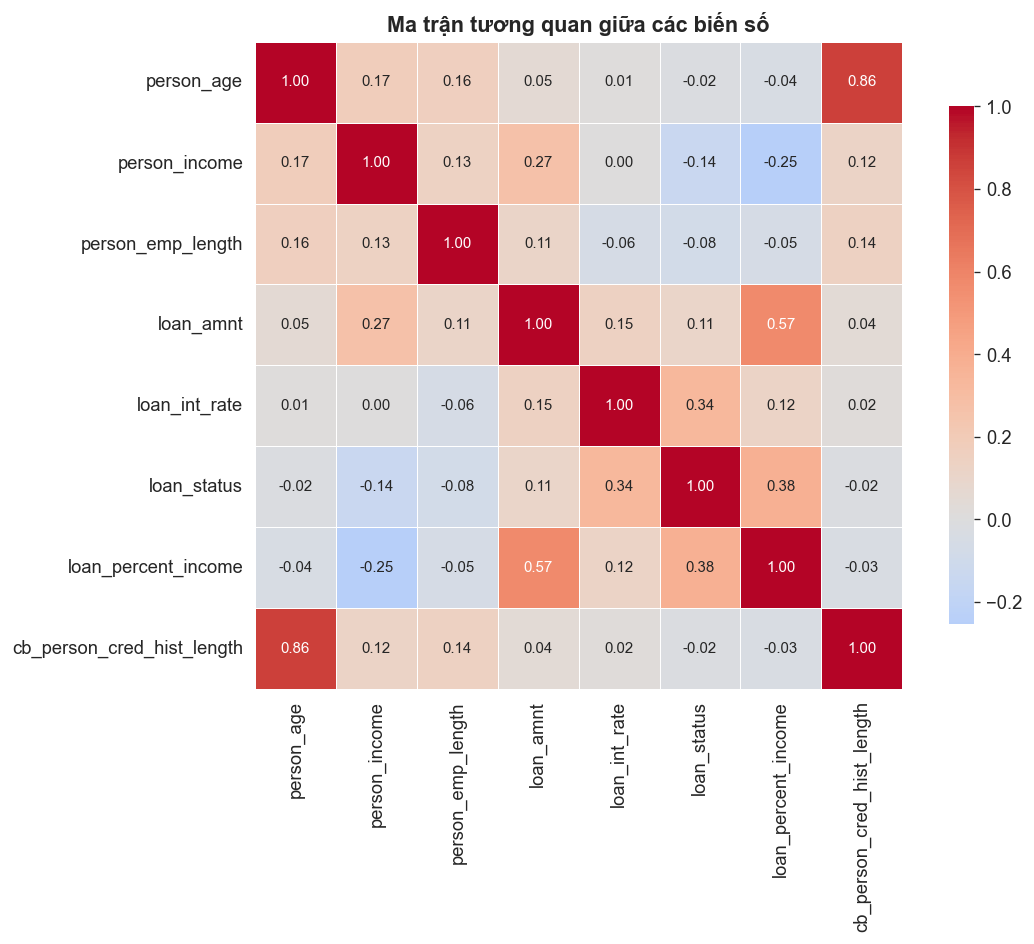

loan_percent_income           0.379
loan_int_rate                 0.335
person_income                 0.144
loan_amnt                     0.105
person_emp_length             0.082
person_age                    0.022
cb_person_cred_hist_length    0.016
Name: loan_status, dtype: float64


In [32]:
cot_so = df.select_dtypes(include=[np.number]).columns.tolist()
corr = df[cot_so].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            square=True, linewidths=0.5, cbar_kws={'shrink': 0.8},
            annot_kws={'size': 9})
plt.title('Ma trận tương quan giữa các biến số')
plt.tight_layout()
plt.show()

print(corr['loan_status'].drop('loan_status').abs().sort_values(ascending=False).round(3))


**Nhận xét:** Tương quan mạnh nhất với `loan_status` là `loan_percent_income` (0,38) và `loan_int_rate` (0,34) — đều ở mức vừa phải, **không có dấu hiệu rò rỉ dữ liệu** (không biến nào > 0,9). Cặp `person_age` ↔ `cb_person_cred_hist_length` tương quan rất cao (0,86) là hợp lý về mặt nghiệp vụ (người lớn tuổi có lịch sử tín dụng dài hơn); cặp này không làm ảnh hưởng đến mô hình cây nhưng đáng lưu ý khi diễn giải hệ số Logistic.


### 2.2. Phân phối các biến số

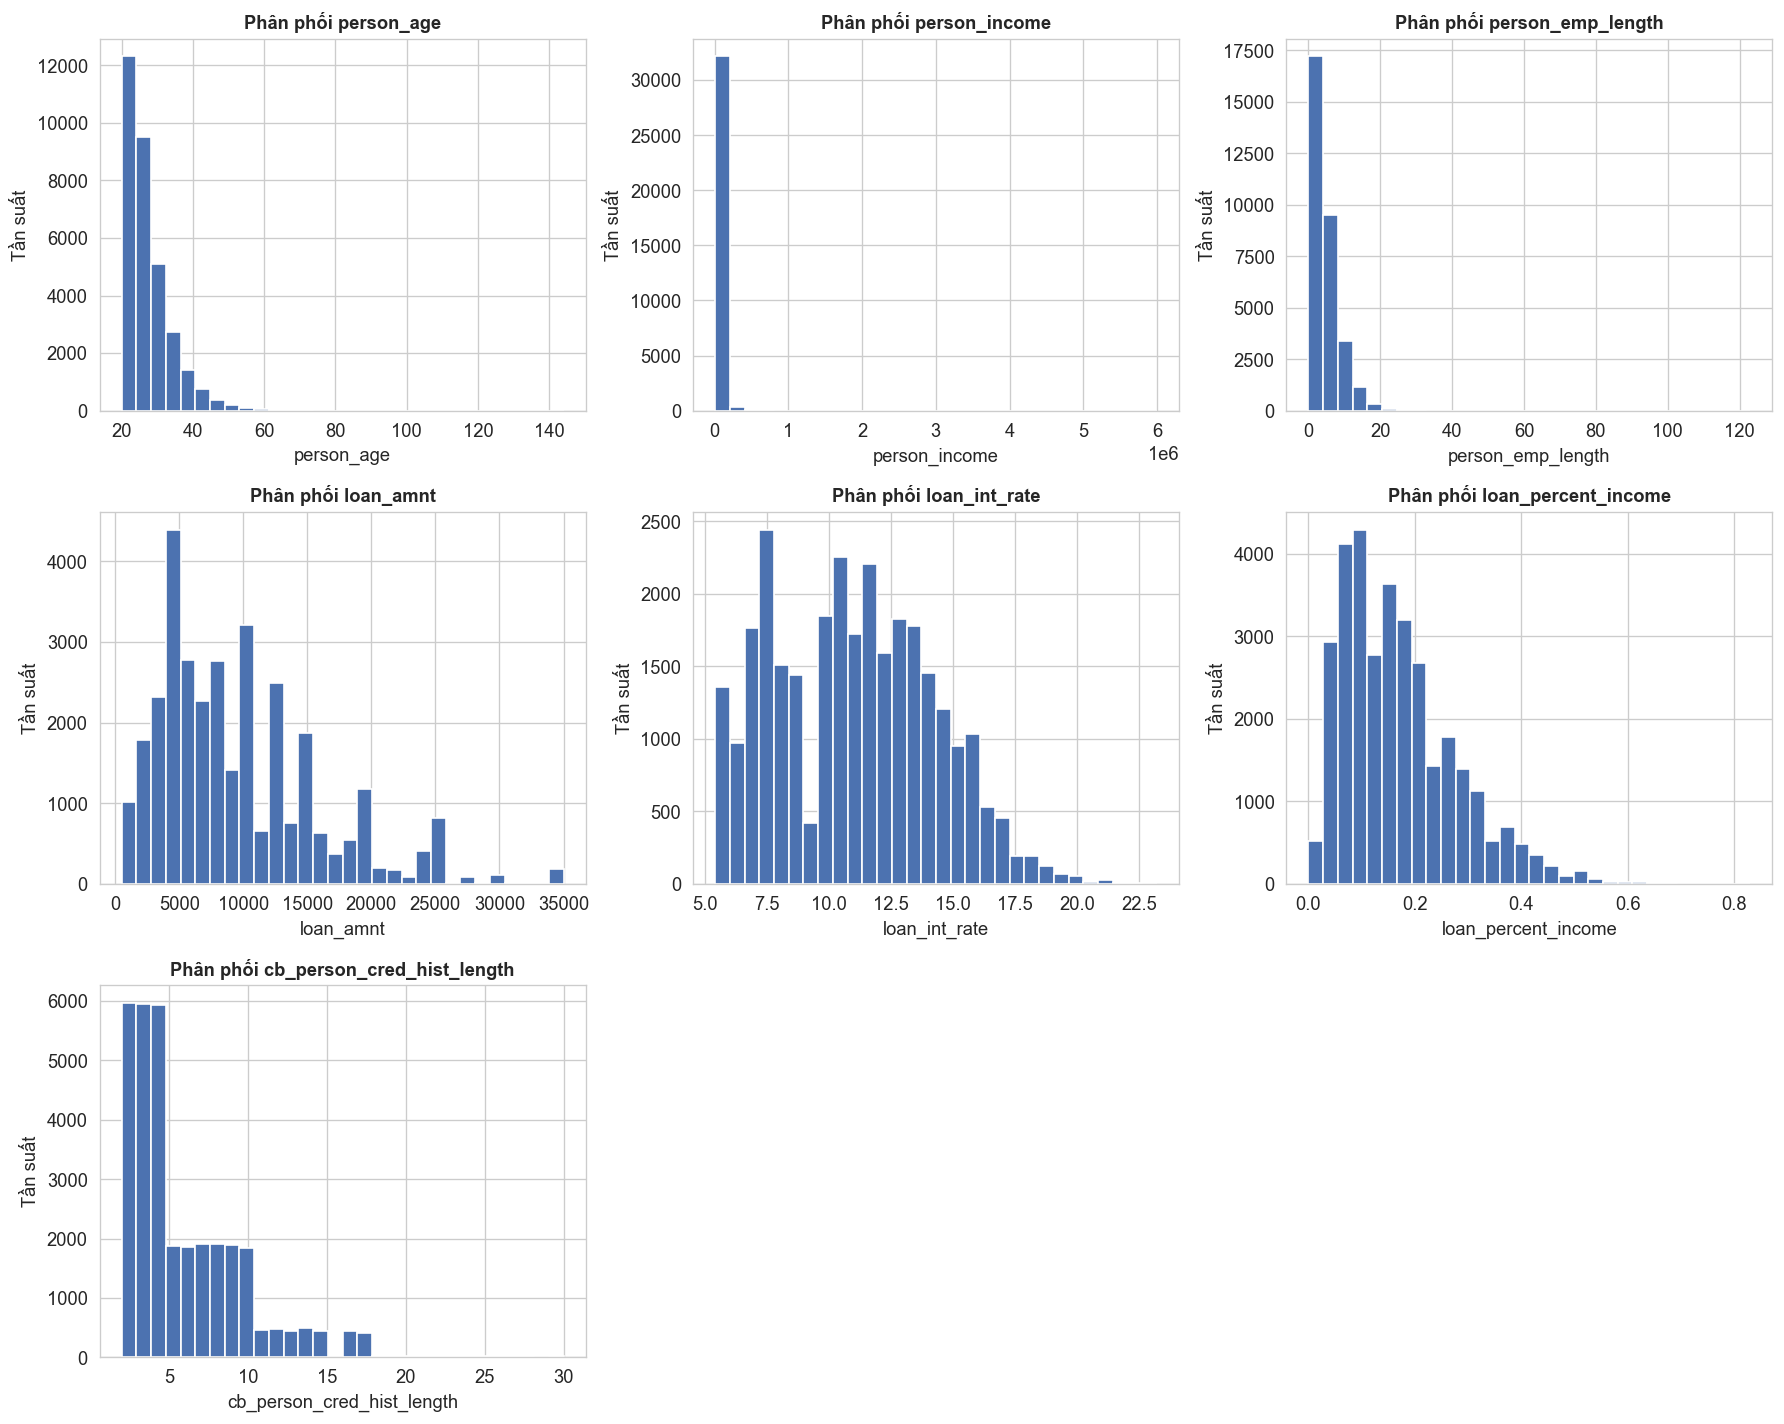

In [33]:
# Phân phối các biến số
num_cols = df.select_dtypes(include=np.number).columns.drop('loan_status')
ncol = 3; nrow = int(np.ceil(len(num_cols)/ncol))
fig, axes = plt.subplots(nrow, ncol, figsize=(15, 4*nrow))
axes = axes.flatten()
for i, col in enumerate(num_cols):
    axes[i].hist(df[col], bins=30, color=sns.color_palette('deep')[0], edgecolor='white')
    axes[i].set_title(f'Phân phối {col}', fontweight='bold', fontsize=11)
    axes[i].set_xlabel(col); axes[i].set_ylabel('Tần suất')
for j in range(len(num_cols), len(axes)): axes[j].axis('off')
plt.tight_layout()
plt.show()


**Nhận xét:** Hầu hết biến số lệch phải mạnh — `person_income`, `loan_amnt`, `person_emp_length` đều có đuôi dài về phía giá trị lớn (số ít khách thu nhập rất cao hoặc vay rất nhiều). `person_age` tập trung ở nhóm 20–35 tuổi (khách hàng trẻ chiếm đa số). Đặc điểm lệch phải này lý giải vì sao mô hình cây (Random Forest, XGBoost) thường hoạt động tốt hơn mô hình tuyến tính: cây không giả định phân phối chuẩn của biến.

### 2.3. Tỷ lệ vỡ nợ theo biến phân loại

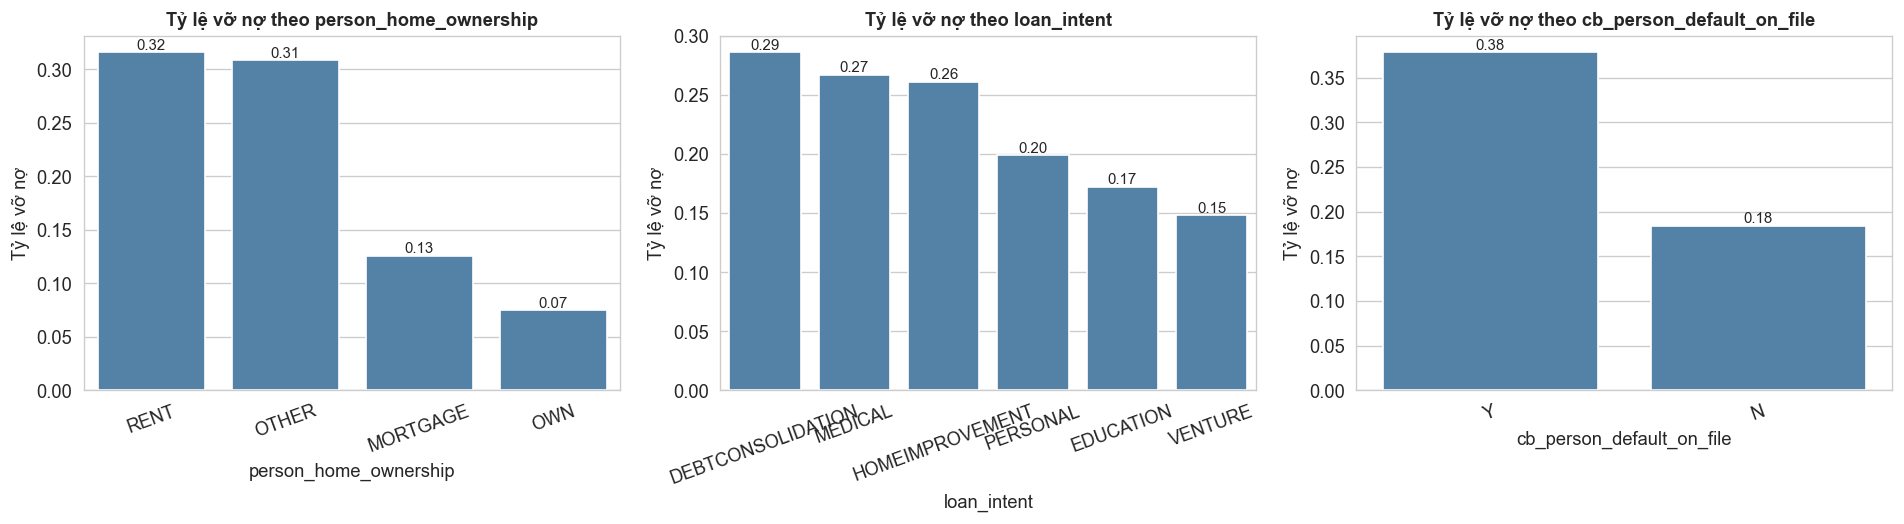


person_home_ownership:
                       count   mean
person_home_ownership              
MORTGAGE               13444  0.126
OTHER                    107  0.308
OWN                     2584  0.075
RENT                   16446  0.316

loan_intent:
                   count   mean
loan_intent                    
DEBTCONSOLIDATION   5212  0.286
EDUCATION           6453  0.172
HOMEIMPROVEMENT     3605  0.261
MEDICAL             6071  0.267
PERSONAL            5521  0.199
VENTURE             5719  0.148

cb_person_default_on_file:
                           count   mean
cb_person_default_on_file              
N                          26836  0.184
Y                           5745  0.378


In [34]:
# Tỷ lệ vỡ nợ theo các biến phân loại
cat_cols = ['person_home_ownership', 'loan_intent', 'cb_person_default_on_file']
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

for i, col in enumerate(cat_cols):
    rt = (
        df.groupby(col, as_index=False)['loan_status']
        .mean()
        .rename(columns={'loan_status': 'default_rate'})
        .sort_values('default_rate', ascending=False)
    )

    sns.barplot(data=rt, x=col, y='default_rate', ax=axes[i], color='steelblue')
    axes[i].set_title(f'Tỷ lệ vỡ nợ theo {col}', fontweight='bold', fontsize=11)
    axes[i].set_ylabel('Tỷ lệ vỡ nợ')
    axes[i].set_xlabel(col)
    axes[i].tick_params(axis='x', rotation=20)

    for p in axes[i].patches:
        axes[i].annotate(
            f'{p.get_height():.2f}',
            (p.get_x() + p.get_width() / 2, p.get_height()),
            ha='center', va='bottom', fontsize=9
        )

plt.tight_layout()
plt.show()

# In bảng số liệu để phục vụ nhận xét
for col in cat_cols:
    print(f'\n{col}:')
    print(df.groupby(col)['loan_status'].agg(['count', 'mean']).round(3).to_string())

**Nhận xét:** Các biến phân loại tạo ra sự khác biệt rõ về tỷ lệ vỡ nợ:

- **Sở hữu nhà:** khách hàng thuê nhà (`RENT`) có tỷ lệ vỡ nợ 31,6%, cao hơn đáng kể nhóm sở hữu nhà (`OWN`) là 7,5% và nhóm có khoản vay thế chấp nhà (`MORTGAGE`) là 12,6%.
- **Mục đích vay:** vay để hợp nhất nợ (`DEBTCONSOLIDATION`) có tỷ lệ vỡ nợ cao nhất, khoảng 28,6%; tiếp theo là vay y tế (`MEDICAL`) 26,7% và sửa chữa nhà (`HOMEIMPROVEMENT`) 26,1%. Vay cho hoạt động kinh doanh (`VENTURE`) có tỷ lệ thấp nhất, khoảng 14,8%.
- **Lịch sử vỡ nợ:** khách hàng từng có default trong lịch sử (`Y`) có tỷ lệ vỡ nợ 37,8%, cao hơn hơn hai lần nhóm chưa từng default (`N`) là 18,4%.

Các kết quả này cho thấy biến phân loại có giá trị trong việc phân khúc rủi ro. Tuy nhiên, ngân hàng không nên sử dụng riêng một đặc điểm như tình trạng nhà ở hoặc mục đích vay để từ chối khách hàng, mà cần kết hợp với khả năng chi trả và lịch sử tín dụng.

### 2.4. So sánh các biến số chính theo nhãn

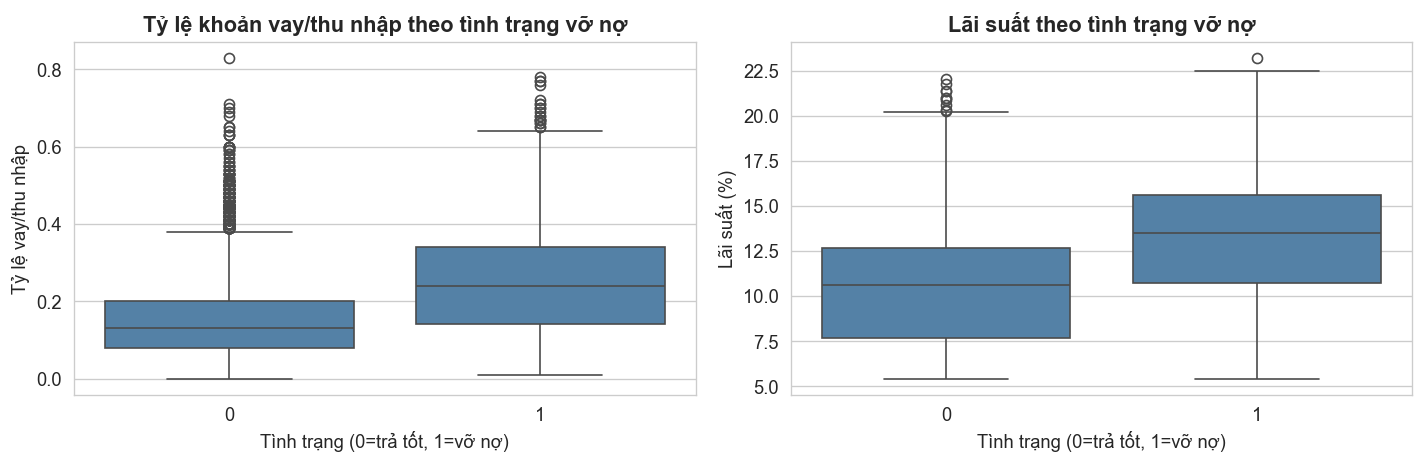

Trung vị tỷ lệ vay/thu nhập: {0: 0.13, 1: 0.24}
Trung vị lãi suất: {0: 10.59, 1: 13.49}


In [35]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.boxplot(x='loan_status', y='loan_percent_income', data=df, ax=axes[0], color='steelblue')
axes[0].set_title('Tỷ lệ khoản vay/thu nhập theo tình trạng vỡ nợ')
axes[0].set_xlabel('Tình trạng (0=trả tốt, 1=vỡ nợ)'); axes[0].set_ylabel('Tỷ lệ vay/thu nhập')
sns.boxplot(x='loan_status', y='loan_int_rate', data=df, ax=axes[1], color='steelblue')
axes[1].set_title('Lãi suất theo tình trạng vỡ nợ')
axes[1].set_xlabel('Tình trạng (0=trả tốt, 1=vỡ nợ)'); axes[1].set_ylabel('Lãi suất (%)')
plt.tight_layout()
plt.show()

print('Trung vị tỷ lệ vay/thu nhập:', df.groupby('loan_status')['loan_percent_income'].median().round(3).to_dict())
print('Trung vị lãi suất:', df.groupby('loan_status')['loan_int_rate'].median().round(2).to_dict())


loan_grade
A    0.100
B    0.163
C    0.207
D    0.590
E    0.644
F    0.705
G    0.984
Name: loan_status, dtype: float64


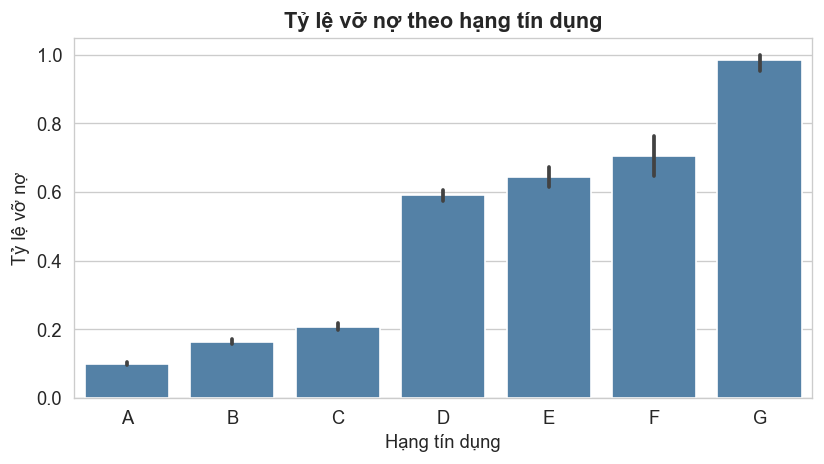

In [36]:
# Tỷ lệ vỡ nợ theo hạng tín dụng
print(df.groupby('loan_grade')['loan_status'].mean().round(3))
plt.figure(figsize=(7, 4))
sns.barplot(x='loan_grade', y='loan_status', data=df, order=list('ABCDEFG'), color='steelblue')
plt.title('Tỷ lệ vỡ nợ theo hạng tín dụng')
plt.xlabel('Hạng tín dụng'); plt.ylabel('Tỷ lệ vỡ nợ')
plt.tight_layout()
plt.show()


**Nhận xét:** Các biến số chính và hạng tín dụng đều phân biệt nhóm vỡ nợ khá rõ. Nhóm vỡ nợ có trung vị tỷ lệ vay/thu nhập là 0,24, gần gấp đôi nhóm trả tốt là 0,13; lãi suất trung vị của nhóm vỡ nợ là 13,49%, cao hơn nhóm trả tốt là 10,59%. Tỷ lệ vỡ nợ tăng đơn điệu theo hạng tín dụng, với bước nhảy lớn từ hạng C (20,7%) sang D (59,0%) và đạt 98,4% ở hạng G. Đây là các biến dự báo tiềm năng mạnh, nhưng cần xác nhận `loan_grade` và `loan_int_rate` đã có sẵn tại thời điểm ra quyết định để tránh sử dụng thông tin phát sinh sau phê duyệt.

### 2.5. Kết luận tổng hợp từ EDA

Phân tích khám phá dữ liệu cho thấy bộ dữ liệu có khả năng hỗ trợ tốt cho bài toán dự báo vỡ nợ, đồng thời chỉ ra một số tín hiệu rủi ro quan trọng:

1. **Nhãn có mức mất cân bằng đáng kể:** nhóm vỡ nợ chiếm khoảng 21,8%, thấp hơn nhóm trả nợ tốt khoảng 3,6 lần. Vì vậy, Accuracy không nên được sử dụng riêng lẻ; Recall, Precision, F1-score và ROC-AUC cần được ưu tiên khi đánh giá mô hình.

2. **Áp lực trả nợ là tín hiệu rủi ro nổi bật:** nhóm vỡ nợ có trung vị `loan_percent_income` là 0,24, gần gấp đôi nhóm trả tốt là 0,13. Điều này cho thấy tỷ lệ khoản vay trên thu nhập có thể phản ánh mức độ căng thẳng tài chính của khách hàng.

3. **Giá khoản vay và chất lượng tín dụng phân biệt rủi ro tốt:** nhóm vỡ nợ có lãi suất trung vị 13,49%, cao hơn nhóm trả tốt là 10,59%. Tỷ lệ vỡ nợ tăng mạnh theo hạng tín dụng, từ 10,0% ở hạng A lên 59,0% ở hạng D và 98,4% ở hạng G.

4. **Đặc điểm nhà ở, mục đích vay và lịch sử tín dụng tạo ra các phân khúc rủi ro khác nhau:** khách hàng thuê nhà có tỷ lệ vỡ nợ 31,6%, cao hơn đáng kể nhóm sở hữu nhà là 7,5%. Các khoản vay để hợp nhất nợ có tỷ lệ vỡ nợ 28,6%, trong khi vay cho hoạt động kinh doanh là 14,8%. Khách hàng từng có lịch sử default có tỷ lệ vỡ nợ 37,8%, cao hơn hơn hai lần nhóm chưa từng default là 18,4%.

5. **Chưa phát hiện dấu hiệu rò rỉ dữ liệu rõ ràng qua tương quan tuyến tính:** các biến tương quan mạnh nhất với `loan_status` là `loan_percent_income` và `loan_int_rate`, nhưng mức tương quan chỉ ở mức vừa phải. Mô hình vẫn cần học sự kết hợp và tương tác giữa nhiều biến thay vì dựa vào một biến duy nhất.

Từ EDA, các nhóm biến cần được chú trọng trong quá trình mô hình hóa và diễn giải gồm: **khả năng chi trả** (`person_income`, `loan_percent_income`), **đặc điểm khoản vay** (`loan_amnt`, `loan_int_rate`, `loan_grade`, `loan_intent`) và **lịch sử/đặc điểm khách hàng** (`cb_person_default_on_file`, `person_home_ownership`, `cb_person_cred_hist_length`).

Về góc độ dữ liệu ngân hàng, cần đặc biệt kiểm tra thời điểm hình thành của `loan_grade` và `loan_int_rate`. Nếu hai biến này chỉ được xác định sau quá trình thẩm định hoặc sau khi khoản vay được phê duyệt, chúng không nên được sử dụng trong mô hình sàng lọc ở đầu quy trình vì có thể tạo ra rò rỉ hoặc tính vòng tròn trong quyết định tín dụng.

# B. Xử lý feature và thiết kế mẫu

## Bước 3: Làm sạch dữ liệu

Nghiên cứu chỉ loại các quan sát có giá trị **phi lý về mặt nghiệp vụ**, gồm tuổi lớn hơn 100 và số năm làm việc lớn hơn 60. Các giá trị thiếu của `loan_int_rate` và `person_emp_length` được giữ lại ở bước làm sạch và sẽ được điền bằng trung vị **trong pipeline của từng mô hình**. Cách xử lý này đảm bảo bộ điền thiếu chỉ học từ tập huấn luyện, hạn chế rò rỉ dữ liệu sang tập kiểm tra.

In [37]:
# Chỉ loại ngoại lai phi lý; GIỮ dòng có giá trị thiếu (sẽ điền trong pipeline)
print('Tuổi > 100:', (df.person_age > 100).sum(), '| Số năm làm việc > 60:', (df.person_emp_length > 60).sum())
df = df[(df.person_age <= 100) & ((df.person_emp_length.isna()) | (df.person_emp_length <= 60))].copy()
print('Số dòng còn lại:', df.shape[0])
print('Giá trị thiếu được giữ lại để xử lý trong pipeline:')
print(df[['loan_int_rate','person_emp_length']].isna().sum())

Tuổi > 100: 5 | Số năm làm việc > 60: 2
Số dòng còn lại: 32574
Giá trị thiếu được giữ lại để xử lý trong pipeline:
loan_int_rate        3115
person_emp_length     895
dtype: int64


**Nhận xét:** Chỉ 7 quan sát bị loại do giá trị phi lý, gần như không ảnh hưởng kích thước mẫu (còn 32.574 dòng). Khác với cách xóa hoặc điền trực tiếp trên toàn bộ dữ liệu, việc giữ giá trị thiếu và điền trong pipeline giúp quy trình đánh giá trung thực hơn về mặt phương pháp.

## Bước 4: Xác định biến và chia Train/Validation/Test

Với hơn 32 nghìn quan sát, nghiên cứu sử dụng ba tập dữ liệu:

- **Train (60%)**: học bin WOE, preprocessing và tham số của ba mô hình.
- **Validation (20%)**: lựa chọn mô hình, calibration và lựa chọn threshold.
- **Test (20%)**: đánh giá cuối cùng, không tham gia bất kỳ quyết định mô hình nào.

Do dữ liệu không có biến thời gian giải ngân/quan sát, bài làm sử dụng chia ngẫu nhiên có phân tầng. Trong triển khai ngân hàng, nên thay tập test bằng **out-of-time sample** để đánh giá khả năng tổng quát hóa theo thời gian.

In [38]:
from sklearn.model_selection import train_test_split

TARGET = 'loan_status'
X = df.drop(columns=[TARGET]).copy()
y = df[TARGET].astype(int).copy()

# 20% test được khóa lại trước
X_dev, X_test, y_dev, y_test = train_test_split(
    X, y, test_size=0.20, random_state=RANDOM_STATE, stratify=y
)
# 25% của 80% dev = 20% toàn bộ dữ liệu
X_train, X_val, y_train, y_val = train_test_split(
    X_dev, y_dev, test_size=0.25, random_state=RANDOM_STATE, stratify=y_dev
)

num_cols = X_train.select_dtypes(include=np.number).columns.tolist()
cat_cols = X_train.select_dtypes(exclude=np.number).columns.tolist()

split_summary = pd.DataFrame({
    'Tập dữ liệu': ['Train', 'Validation', 'Test'],
    'Số quan sát': [len(X_train), len(X_val), len(X_test)],
    'Tỷ trọng mẫu': [len(X_train)/len(X), len(X_val)/len(X), len(X_test)/len(X)],
    'Tỷ lệ vỡ nợ': [y_train.mean(), y_val.mean(), y_test.mean()]
})
display(split_summary.style.format({'Tỷ trọng mẫu':'{:.1%}', 'Tỷ lệ vỡ nợ':'{:.2%}'}))
print('Biến số:', num_cols)
print('Biến phân loại:', cat_cols)

,Tập dữ liệu,Số quan sát,Tỷ trọng mẫu,Tỷ lệ vỡ nợ
0,Train,19544,60.0%,21.82%
1,Validation,6515,20.0%,21.83%
2,Test,6515,20.0%,21.81%


Biến số: ['person_age', 'person_income', 'person_emp_length', 'loan_amnt', 'loan_int_rate', 'loan_percent_income', 'cb_person_cred_hist_length']
Biến phân loại: ['person_home_ownership', 'loan_intent', 'loan_grade', 'cb_person_default_on_file']


**Nhận xét:** Sau làm sạch, dữ liệu được chia thành 19.544 quan sát train, 6.515 validation và 6.515 test. Tỷ lệ vỡ nợ lần lượt là 21,82%, 21,83% và 21,81%, cho thấy `stratify` đã giữ cấu trúc nhãn gần như không đổi. Validation được dành riêng cho lựa chọn mô hình, calibration và threshold; test chỉ được mở ở bước đánh giá cuối.

## Bước 5: Đánh giá dịch chuyển dữ liệu bằng PSI

Population Stability Index đo mức thay đổi phân phối giữa mẫu tham chiếu và mẫu so sánh:

- `PSI < 0,10`: phân phối ổn định.
- `0,10 ≤ PSI < 0,25`: có dịch chuyển mức vừa, cần theo dõi.
- `PSI ≥ 0,25`: dịch chuyển đáng kể, cần điều tra nguyên nhân.

Các khoảng của biến số được xác định **chỉ từ tập train** rồi áp dụng sang validation/test. Với biến phân loại, nhóm chưa xuất hiện ở train được gom vào `__OTHER__`. Vì dữ liệu được chia ngẫu nhiên, PSI ở đây đánh giá tính đồng nhất giữa các mẫu; khi triển khai cần tính PSI theo tháng/vintage trên dữ liệu thực tế.

,Biến,PSI_Validation,PSI_Test,PSI_max,Mức độ
0,person_income,0.0031,0.0021,0.0031,Ổn định
1,loan_int_rate,0.0016,0.0031,0.0031,Ổn định
2,person_age,0.0014,0.0027,0.0027,Ổn định
3,loan_amnt,0.0020,0.0016,0.0020,Ổn định
4,loan_percent_income,0.0018,0.0005,0.0018,Ổn định
5,cb_person_cred_hist_length,0.0010,0.0015,0.0015,Ổn định
6,loan_grade,0.0014,0.0008,0.0014,Ổn định
7,person_home_ownership,0.0012,0.0008,0.0012,Ổn định
8,person_emp_length,0.0010,0.0010,0.0010,Ổn định
9,loan_intent,0.0008,0.0000,0.0008,Ổn định


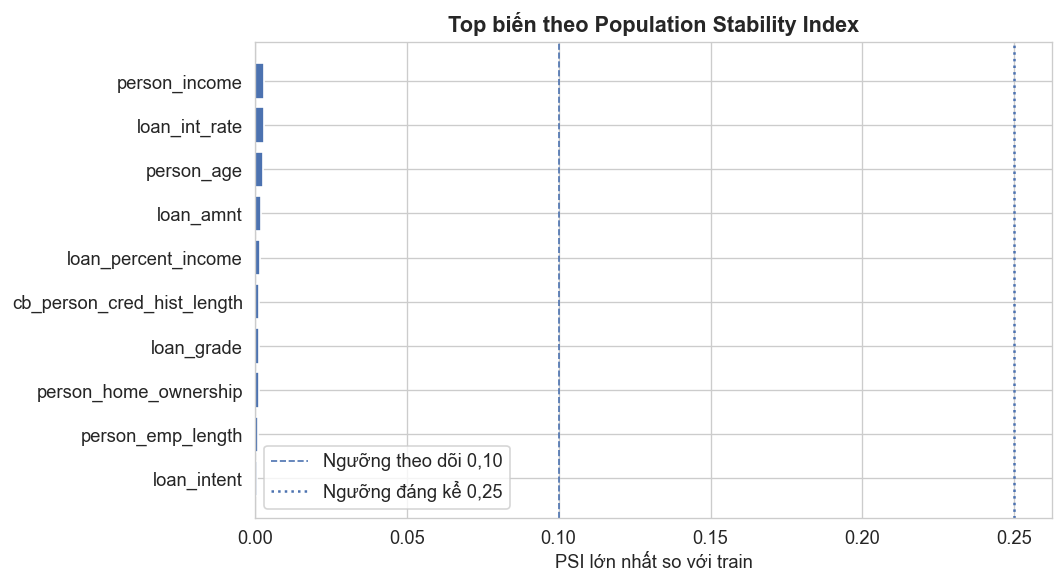

PSI của tỷ lệ nhãn — Train vs Validation: 0.0
PSI của tỷ lệ nhãn — Train vs Test      : 0.0


In [39]:
def _psi_from_props(expected_prop, actual_prop, eps=1e-6):
    expected_prop = np.clip(np.asarray(expected_prop, dtype=float), eps, None)
    actual_prop = np.clip(np.asarray(actual_prop, dtype=float), eps, None)
    return np.sum((actual_prop - expected_prop) * np.log(actual_prop / expected_prop))


def psi_numeric(expected, actual, bins=10):
    exp = pd.to_numeric(expected, errors='coerce')
    act = pd.to_numeric(actual, errors='coerce')
    valid = exp.dropna()
    if valid.nunique() <= 2:
        return psi_categorical(exp.astype('object'), act.astype('object'))

    quantiles = np.unique(np.nanquantile(valid, np.linspace(0, 1, bins + 1)))
    inner = quantiles[1:-1]
    edges = np.r_[-np.inf, inner, np.inf]

    exp_bin = pd.cut(exp, bins=edges, include_lowest=True).astype(str)
    act_bin = pd.cut(act, bins=edges, include_lowest=True).astype(str)
    exp_bin = exp_bin.where(exp.notna(), '__MISSING__')
    act_bin = act_bin.where(act.notna(), '__MISSING__')

    levels = sorted(set(exp_bin.unique()) | set(act_bin.unique()))
    exp_prop = exp_bin.value_counts(normalize=True).reindex(levels, fill_value=0)
    act_prop = act_bin.value_counts(normalize=True).reindex(levels, fill_value=0)
    return _psi_from_props(exp_prop.values, act_prop.values)


def psi_categorical(expected, actual):
    exp = expected.astype('object').where(expected.notna(), '__MISSING__').astype(str)
    act = actual.astype('object').where(actual.notna(), '__MISSING__').astype(str)
    known = set(exp.unique())
    act = act.where(act.isin(known), '__OTHER__')
    levels = sorted(known | {'__OTHER__'})
    exp_prop = exp.value_counts(normalize=True).reindex(levels, fill_value=0)
    act_prop = act.value_counts(normalize=True).reindex(levels, fill_value=0)
    return _psi_from_props(exp_prop.values, act_prop.values)


def feature_psi_table(X_reference, X_compare, compare_name):
    rows = []
    for col in X_reference.columns:
        if pd.api.types.is_numeric_dtype(X_reference[col]):
            value = psi_numeric(X_reference[col], X_compare[col])
        else:
            value = psi_categorical(X_reference[col], X_compare[col])
        rows.append({'Biến': col, f'PSI_{compare_name}': value})
    return pd.DataFrame(rows)

psi_val = feature_psi_table(X_train, X_val, 'Validation')
psi_test = feature_psi_table(X_train, X_test, 'Test')
psi_features = psi_val.merge(psi_test, on='Biến')
psi_features['PSI_max'] = psi_features[['PSI_Validation','PSI_Test']].max(axis=1)
psi_features['Mức độ'] = pd.cut(
    psi_features['PSI_max'], [-np.inf, 0.10, 0.25, np.inf],
    labels=['Ổn định', 'Theo dõi', 'Dịch chuyển đáng kể'], right=False
)
psi_features = psi_features.sort_values('PSI_max', ascending=False).reset_index(drop=True)

display(psi_features.style.format({
    'PSI_Validation':'{:.4f}', 'PSI_Test':'{:.4f}', 'PSI_max':'{:.4f}'
}))

plt.figure(figsize=(9,5))
plot_psi = psi_features.head(10).sort_values('PSI_max')
plt.barh(plot_psi['Biến'], plot_psi['PSI_max'])
plt.axvline(0.10, linestyle='--', linewidth=1, label='Ngưỡng theo dõi 0,10')
plt.axvline(0.25, linestyle=':', linewidth=1.5, label='Ngưỡng đáng kể 0,25')
plt.xlabel('PSI lớn nhất so với train')
plt.title('Top biến theo Population Stability Index')
plt.legend()
plt.tight_layout()
plt.show()

print('PSI của tỷ lệ nhãn — Train vs Validation:', round(psi_categorical(y_train, y_val), 6))
print('PSI của tỷ lệ nhãn — Train vs Test      :', round(psi_categorical(y_train, y_test), 6))

**Nhận xét PSI:** Toàn bộ biến có PSI rất thấp. Giá trị lớn nhất chỉ khoảng 0,0031, xuất hiện ở `person_income` khi so train với validation và `loan_int_rate` khi so train với test; thấp hơn rất xa ngưỡng theo dõi 0,10. PSI của tỷ lệ nhãn bằng 0 do ba tập có bad rate gần như giống nhau. Như vậy, chưa phát hiện sample drift giữa train–validation–test. Tuy nhiên, đây chỉ là kiểm tra độ đồng nhất của phép chia ngẫu nhiên, không chứng minh dữ liệu ổn định theo thời gian. Khi triển khai, PSI cần được tính theo tháng/vintage và theo từng phân khúc sản phẩm, kênh bán, khu vực.

## Bước 6: Kiểm tra đa cộng tuyến sơ bộ bằng VIF

VIF được tính trên các biến số của tập train sau khi điền trung vị chỉ cho mục đích chẩn đoán. WOE Logistic sẽ được đánh giá thêm bằng dấu hệ số; nếu dấu bị đảo, cần xem xét đa cộng tuyến, binning không đơn điệu hoặc biến bị leakage.

In [40]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant

X_vif_raw = X_train[num_cols].astype(float)
X_vif_filled = X_vif_raw.fillna(X_vif_raw.median())
X_vif = add_constant(X_vif_filled)
vif_df = pd.DataFrame({
    'Biến': X_vif.columns,
    'VIF': [variance_inflation_factor(X_vif.values, i) for i in range(X_vif.shape[1])]
})
display(vif_df[vif_df['Biến'] != 'const'].sort_values('VIF', ascending=False).style.format({'VIF':'{:.2f}'}))

,Biến,VIF
1,person_age,4.43
7,cb_person_cred_hist_length,4.39
4,loan_amnt,2.48
6,loan_percent_income,2.43
2,person_income,1.81
3,person_emp_length,1.06
5,loan_int_rate,1.02


## Bước 7: Phát triển Logistic Regression theo WOE và IV

### Quy ước

Nghiên cứu định nghĩa:

`WOE = ln(Tỷ trọng Good / Tỷ trọng Bad)`

với `Bad = loan_status = 1`. Vì WOE lớn thể hiện nhóm có rủi ro thấp hơn, hệ số Logistic dự báo default **kỳ vọng mang dấu âm**. Hệ số dương được gắn cờ để kiểm tra lại.

Information Value được dùng để sàng lọc sức mạnh phân biệt đơn biến:

- `< 0,02`: rất yếu;
- `0,02–<0,10`: yếu;
- `0,10–<0,30`: trung bình;
- `0,30–<0,50`: mạnh;
- `≥ 0,50`: rất mạnh, đồng thời cần kiểm tra leakage.

Binning và WOE được fit hoàn toàn trên tập train. Validation/test chỉ được transform bằng các bin và mapping đã học.

In [41]:
from sklearn.base import BaseEstimator, TransformerMixin

class WOEEncoder(BaseEstimator, TransformerMixin):
    """WOE encoder đơn giản, fit bin/mapping trên train để tránh leakage."""
    def __init__(self, numeric_cols=None, categorical_cols=None, n_bins=10, smoothing=0.5):
        self.numeric_cols = numeric_cols
        self.categorical_cols = categorical_cols
        self.n_bins = n_bins
        self.smoothing = smoothing

    def _numeric_key(self, s, edges):
        x = pd.to_numeric(s, errors='coerce')
        key = pd.cut(x, bins=edges, labels=False, include_lowest=True)
        key = key.astype('Int64').astype(str)
        key = key.where(x.notna(), '__MISSING__')
        return key

    def _categorical_key(self, s):
        return s.astype('object').where(s.notna(), '__MISSING__').astype(str)

    def fit(self, X, y):
        X = pd.DataFrame(X).copy()
        y = pd.Series(y, index=X.index).astype(int)
        self.feature_names_in_ = list(X.columns)
        self.numeric_cols_ = list(self.numeric_cols or [])
        self.categorical_cols_ = list(self.categorical_cols or [])
        self.bin_edges_ = {}
        self.woe_maps_ = {}
        self.iv_ = {}
        self.detail_tables_ = {}

        total_good = (y == 0).sum()
        total_bad = (y == 1).sum()

        for col in self.feature_names_in_:
            if col in self.numeric_cols_:
                values = pd.to_numeric(X[col], errors='coerce')
                valid = values.dropna()
                if valid.nunique() > 2:
                    q = np.unique(np.nanquantile(valid, np.linspace(0, 1, self.n_bins + 1)))
                    edges = np.r_[-np.inf, q[1:-1], np.inf]
                else:
                    edges = np.array([-np.inf, np.inf])
                self.bin_edges_[col] = edges
                key = self._numeric_key(values, edges)
            else:
                key = self._categorical_key(X[col])

            tab = pd.crosstab(key, y).reindex(columns=[0,1], fill_value=0)
            tab.columns = ['Good', 'Bad']
            k = max(len(tab), 1)
            tab['Dist_Good'] = (tab['Good'] + self.smoothing) / (total_good + self.smoothing * k)
            tab['Dist_Bad'] = (tab['Bad'] + self.smoothing) / (total_bad + self.smoothing * k)
            tab['WOE'] = np.log(tab['Dist_Good'] / tab['Dist_Bad'])
            tab['IV_Component'] = (tab['Dist_Good'] - tab['Dist_Bad']) * tab['WOE']
            self.woe_maps_[col] = tab['WOE'].to_dict()
            self.iv_[col] = float(tab['IV_Component'].sum())
            self.detail_tables_[col] = tab.reset_index().rename(columns={tab.index.name or 'row_0':'Bin'})
        return self

    def transform(self, X):
        X = pd.DataFrame(X).copy()
        out = pd.DataFrame(index=X.index)
        for col in self.feature_names_in_:
            if col in self.numeric_cols_:
                key = self._numeric_key(X[col], self.bin_edges_[col])
            else:
                key = self._categorical_key(X[col])
            out[col] = key.map(self.woe_maps_[col]).fillna(0.0).astype(float)
        return out

    def get_feature_names_out(self, input_features=None):
        return np.asarray(self.feature_names_in_, dtype=object)

    def iv_summary(self):
        result = pd.DataFrame({'Biến': list(self.iv_.keys()), 'IV': list(self.iv_.values())})
        result['Mức độ'] = pd.cut(
            result['IV'], [-np.inf,0.02,0.10,0.30,0.50,np.inf],
            labels=['Rất yếu','Yếu','Trung bình','Mạnh','Rất mạnh / kiểm tra leakage'],
            right=False
        )
        return result.sort_values('IV', ascending=False).reset_index(drop=True)


# C. Xây dựng mô hình baseline và challenger

## Bước 8: Xây dựng mô hình baseline và challenger trên tập Train

Ba mô hình ban đầu được xây dựng để tạo mốc so sánh:

- **Baseline:** WOE Logistic Regression — phù hợp với logic scorecard và có khả năng giải thích cao.
- **Challenger 1:** Random Forest — mô hình bagging có khả năng học quan hệ phi tuyến.
- **Challenger 2:** XGBoost — mô hình boosting tối ưu tuần tự sai số và thường mạnh trên dữ liệu dạng bảng.

Ở bước này, Random Forest và XGBoost sử dụng cấu hình khởi tạo hợp lý nhưng **chưa tuning**. Việc tuning được thực hiện riêng bằng `RandomizedSearchCV` chỉ trên tập Train.

In [42]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

# Baseline: Logistic theo WOE
lr_baseline = Pipeline([
    ('woe', WOEEncoder(
        numeric_cols=num_cols,
        categorical_cols=cat_cols,
        n_bins=10,
        smoothing=0.5
    )),
    ('clf', LogisticRegression(
        C=0.5,
        max_iter=3000,
        class_weight='balanced',
        random_state=RANDOM_STATE
    ))
])
lr_baseline.fit(X_train, y_train)

# Preprocessing dùng chung cho các mô hình cây
num_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='median'))
])

cat_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

tree_prep = ColumnTransformer([
    ('num', num_pipe, num_cols),
    ('cat', cat_pipe, cat_cols)
], remainder='drop', verbose_feature_names_out=False)

# Challenger ban đầu: Random Forest
rf_baseline = Pipeline([
    ('prep', tree_prep),
    ('clf', RandomForestClassifier(
        n_estimators=250,
        max_depth=20,
        min_samples_split=2,
        min_samples_leaf=1,
        max_features='sqrt',
        class_weight='balanced',
        random_state=RANDOM_STATE,
        n_jobs=1
    ))
])
rf_baseline.fit(X_train, y_train)

# Challenger ban đầu: XGBoost
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

xgb_baseline = Pipeline([
    ('prep', tree_prep),
    ('clf', XGBClassifier(
        n_estimators=300,
        learning_rate=0.10,
        max_depth=4,
        min_child_weight=1,
        subsample=0.90,
        colsample_bytree=0.90,
        objective='binary:logistic',
        eval_metric='logloss',
        tree_method='hist',
        scale_pos_weight=scale_pos_weight,
        random_state=RANDOM_STATE,
        n_jobs=1
    ))
])
xgb_baseline.fit(X_train, y_train)

print('Đã fit baseline và hai challenger trên tập Train.')
print('Baseline       : WOE Logistic Regression')
print('Challenger 1   : Random Forest')
print('Challenger 2   : XGBoost')
print('Tuning sẽ được thực hiện bằng RandomizedSearchCV ở bước tiếp theo.')

Đã fit baseline và hai challenger trên tập Train.
Baseline       : WOE Logistic Regression
Challenger 1   : Random Forest
Challenger 2   : XGBoost
Tuning sẽ được thực hiện bằng RandomizedSearchCV ở bước tiếp theo.


## Bước 9: Đánh giá IV và kiểm định dấu hệ số của WOE Logistic

In [43]:
woe_encoder = lr_baseline.named_steps['woe']
iv_table = woe_encoder.iv_summary()
display(iv_table.style.format({'IV':'{:.4f}'}))

coef_table = pd.DataFrame({
    'Biến': woe_encoder.get_feature_names_out(),
    'Hệ số Logistic': lr_baseline.named_steps['clf'].coef_[0]
})
coef_table['Dấu kỳ vọng'] = 'Âm'
coef_table['Đúng dấu'] = coef_table['Hệ số Logistic'] < 0
coef_table['Odds ratio khi WOE tăng 1 đơn vị'] = np.exp(coef_table['Hệ số Logistic'])
coef_table = coef_table.sort_values('Hệ số Logistic')
display(coef_table.style.format({
    'Hệ số Logistic':'{:.4f}',
    'Odds ratio khi WOE tăng 1 đơn vị':'{:.4f}'
}))

n_wrong = (~coef_table['Đúng dấu']).sum()
print(f'Số biến có hệ số không đúng dấu kỳ vọng: {n_wrong}/{len(coef_table)}')

# Kiểm định suy luận hệ số bằng statsmodels trên dữ liệu WOE train
import statsmodels.api as sm
X_train_woe = woe_encoder.transform(X_train)
X_train_woe_sm = sm.add_constant(X_train_woe, has_constant='add')
logit_inference = sm.Logit(y_train, X_train_woe_sm).fit(disp=False, maxiter=300)
ci = logit_inference.conf_int()
inference_table = pd.DataFrame({
    'Biến': logit_inference.params.index,
    'Hệ số': logit_inference.params.values,
    'P-value': logit_inference.pvalues.values,
    'CI 2.5%': ci[0].values,
    'CI 97.5%': ci[1].values
})
inference_table['Đúng dấu kỳ vọng'] = np.where(
    inference_table['Biến'].eq('const'), np.nan, inference_table['Hệ số'] < 0
)
inference_table['Ý nghĩa thống kê 5%'] = inference_table['P-value'] < 0.05
display(inference_table.style.format({
    'Hệ số':'{:.4f}','P-value':'{:.3e}','CI 2.5%':'{:.4f}','CI 97.5%':'{:.4f}'
}))


,Biến,IV,Mức độ
0,loan_percent_income,0.8660,Rất mạnh / kiểm tra leakage
1,loan_grade,0.8567,Rất mạnh / kiểm tra leakage
2,loan_int_rate,0.6474,Rất mạnh / kiểm tra leakage
3,person_income,0.4731,Mạnh
4,person_home_ownership,0.3616,Mạnh
5,cb_person_default_on_file,0.1496,Trung bình
6,loan_intent,0.0876,Yếu
7,loan_amnt,0.0867,Yếu
8,person_emp_length,0.0630,Yếu
9,person_age,0.0130,Rất yếu


,Biến,Hệ số Logistic,Dấu kỳ vọng,Đúng dấu,Odds ratio khi WOE tăng 1 đơn vị
4,loan_intent,-1.3745,Âm,True,0.2530
5,loan_grade,-1.0980,Âm,True,0.3335
1,person_income,-0.8905,Âm,True,0.4104
8,loan_percent_income,-0.8836,Âm,True,0.4133
2,person_home_ownership,-0.7248,Âm,True,0.4844
10,cb_person_cred_hist_length,-0.6516,Âm,True,0.5212
6,loan_amnt,-0.4285,Âm,True,0.6515
3,person_emp_length,-0.2430,Âm,True,0.7842
0,person_age,-0.1644,Âm,True,0.8484
7,loan_int_rate,-0.1398,Âm,True,0.8696


Số biến có hệ số không đúng dấu kỳ vọng: 1/11


,Biến,Hệ số,P-value,CI 2.5%,CI 97.5%,Đúng dấu kỳ vọng,Ý nghĩa thống kê 5%
0,const,-1.3691,0.000e+00,-1.4157,-1.3225,nan,True
1,person_age,-0.2322,2.902e-01,-0.6625,0.1980,1.000000,False
2,person_income,-0.8236,8.998e-90,-0.9039,-0.7432,1.000000,True
3,person_home_ownership,-0.9409,1.403e-128,-1.0173,-0.8644,1.000000,True
4,person_emp_length,-0.4705,5.575e-07,-0.6548,-0.2863,1.000000,True
5,loan_intent,-1.4550,1.194e-77,-1.6079,-1.3021,1.000000,True
6,loan_grade,-1.1601,1.223e-136,-1.2515,-1.0687,1.000000,True
7,loan_amnt,-0.4494,5.083e-06,-0.6425,-0.2563,1.000000,True
8,loan_int_rate,-0.0867,1.026e-01,-0.1908,0.0174,1.000000,False
9,loan_percent_income,-0.9567,6.393e-242,-1.0131,-0.9002,1.000000,True


### Nhận xét WOE, IV và hệ số Logistic

- Ba biến có IV rất cao là `loan_percent_income` (0,8660), `loan_grade` (0,8567) và `loan_int_rate` (0,6474). Đây là các biến phân biệt Good/Bad mạnh, nhưng IV vượt 0,50 cũng là tín hiệu phải rà soát leakage hoặc tính vòng tròn nghiệp vụ. Đặc biệt, cần xác nhận `loan_grade` và `loan_int_rate` có sẵn tại thời điểm mô hình chấm điểm hay chỉ được tạo ra sau thẩm định.
- `person_income` (IV 0,4731) và `person_home_ownership` (IV 0,3616) có sức phân biệt mạnh. `person_age` và `cb_person_cred_hist_length` có IV rất thấp, cho thấy khả năng phân biệt đơn biến hạn chế.
- Trong mô hình sklearn có regularization và class weight, 10/11 hệ số mang dấu âm đúng kỳ vọng. Riêng `cb_person_default_on_file` có hệ số dương rất nhỏ 0,0246.
- Kiểm định suy luận bằng `statsmodels` cho thấy hệ số của `cb_person_default_on_file` không có ý nghĩa thống kê (`p = 0,3744`) và sai dấu; `person_age` (`p = 0,2902`) và `loan_int_rate` (`p = 0,1026`) cũng chưa có ý nghĩa ở mức 5%. Các biến này cần được re-bin, kiểm tra tương quan với `loan_grade`, hoặc thử loại khỏi scorecard rồi so sánh AUC/Brier/độ ổn định.

Không nên tự động loại biến chỉ dựa trên p-value hoặc dấu. Quyết định cuối cần kết hợp ý nghĩa nghiệp vụ, tính đơn điệu của bad rate, độ ổn định PSI và kết quả kiểm định ngoài thời gian.

## Bước 10: So sánh baseline và challenger ban đầu trên Validation

Bảng này tạo mốc hiệu quả trước tuning. Các chỉ tiêu được đọc đồng thời:

- **ROC-AUC:** khả năng xếp hạng khách hàng rủi ro.
- **Recall:** khả năng phát hiện khách hàng thực sự default.
- **Precision:** mức độ chính xác của cảnh báo default.
- **F1-score:** cân bằng Precision và Recall.
- **Brier Score:** sai số xác suất; càng thấp càng tốt.

,Model,Accuracy,Precision,Recall,F1-score,ROC-AUC,Brier,TN,FP,FN,TP
0,XGBoost Baseline,0.9085,0.7844,0.8010,0.7926,0.9463,0.0712,4780,313,283,1139
1,Random Forest Baseline,0.9329,0.9722,0.7131,0.8227,0.9335,0.0590,5064,29,408,1014
2,WOE Logistic Regression,0.8150,0.5516,0.8158,0.6582,0.8823,0.1335,4150,943,262,1160


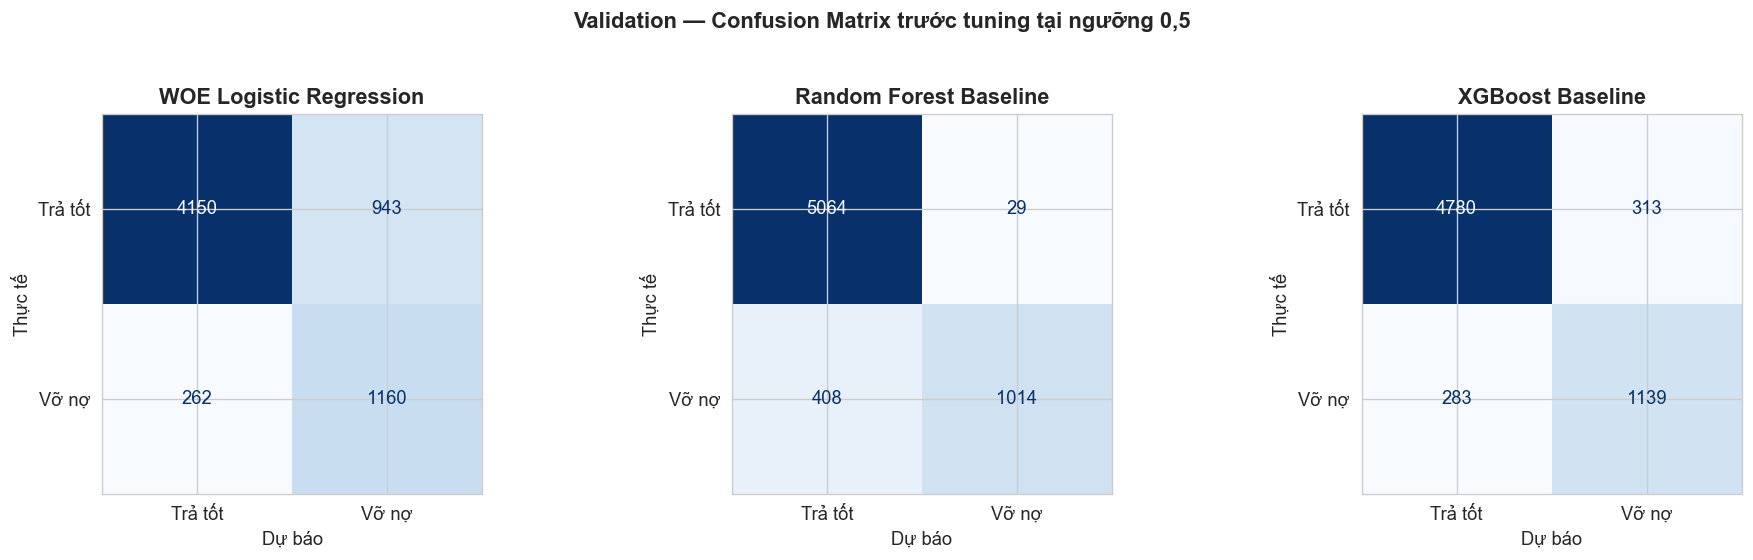

In [44]:
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score,
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    brier_score_loss, log_loss
)

baseline_models = {
    'WOE Logistic Regression': lr_baseline,
    'Random Forest Baseline': rf_baseline,
    'XGBoost Baseline': xgb_baseline
}

baseline_val_rows = []
baseline_val_prob = {}

for name, model in baseline_models.items():
    probability = model.predict_proba(X_val)[:, 1]
    prediction = (probability >= 0.5).astype(int)
    cm = confusion_matrix(y_val, prediction)

    baseline_val_prob[name] = probability
    baseline_val_rows.append({
        'Model': name,
        'Accuracy': accuracy_score(y_val, prediction),
        'Precision': precision_score(y_val, prediction, zero_division=0),
        'Recall': recall_score(y_val, prediction, zero_division=0),
        'F1-score': f1_score(y_val, prediction, zero_division=0),
        'ROC-AUC': roc_auc_score(y_val, probability),
        'Brier': brier_score_loss(y_val, probability),
        'TN': cm[0, 0],
        'FP': cm[0, 1],
        'FN': cm[1, 0],
        'TP': cm[1, 1]
    })

baseline_val_comparison = (
    pd.DataFrame(baseline_val_rows)
      .sort_values('ROC-AUC', ascending=False)
      .reset_index(drop=True)
)

display(baseline_val_comparison.style.format({
    'Accuracy': '{:.4f}',
    'Precision': '{:.4f}',
    'Recall': '{:.4f}',
    'F1-score': '{:.4f}',
    'ROC-AUC': '{:.4f}',
    'Brier': '{:.4f}'
}))

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
for ax, (name, probability) in zip(axes, baseline_val_prob.items()):
    cm = confusion_matrix(y_val, (probability >= 0.5).astype(int))
    ConfusionMatrixDisplay(
        cm,
        display_labels=['Trả tốt', 'Vỡ nợ']
    ).plot(ax=ax, cmap='Blues', colorbar=False)
    ax.set_title(name)
    ax.set_xlabel('Dự báo')
    ax.set_ylabel('Thực tế')

plt.suptitle(
    'Validation — Confusion Matrix trước tuning tại ngưỡng 0,5',
    y=1.03,
    fontweight='bold'
)
plt.tight_layout()
plt.show()

### Nhận xét baseline

- **XGBoost** có ROC-AUC cao nhất, đạt 0,9463 và Recall 0,8010; phù hợp khi ưu tiên phát hiện khách hàng vỡ nợ.
- **Random Forest** đạt Accuracy 0,9329, Precision 0,9722 và F1-score 0,8227, cho thấy mô hình rất thận trọng khi gắn nhãn rủi ro nhưng bỏ sót nhiều default hơn XGBoost.
- **WOE Logistic Regression** đạt ROC-AUC 0,8823 và Recall 0,8158 nhưng Precision chỉ 0,5516 tại ngưỡng 0,5 do sử dụng `class_weight='balanced'`. Mô hình có lợi thế về diễn giải và scorecard, nhưng cần calibration trước khi đọc đầu ra như xác suất.

Kết quả tại bước này chỉ được dùng làm **mốc trước tuning**. Không lựa chọn mô hình cuối dựa trên duy nhất Accuracy, vì tập dữ liệu mất cân bằng và chi phí bỏ sót khách hàng default khác với chi phí cảnh báo nhầm khách hàng tốt.

Hai challenger sẽ được tuning bằng ROC-AUC trên cross-validation của tập Train. Sau đó, kết quả trước và sau tuning được so sánh trên Validation.

# D. Tinh chỉnh siêu tham số và lựa chọn challenger

## Bước 11: Tuning Random Forest và XGBoost bằng RandomizedSearchCV

`RandomizedSearchCV` chỉ sử dụng **tập Train** kết hợp `StratifiedKFold`. Tiêu chí tối ưu chính là ROC-AUC vì đây là chỉ tiêu phù hợp để đo khả năng xếp hạng rủi ro và không phụ thuộc một threshold duy nhất.

In [45]:
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold
from sklearn.base import clone

cv_strategy = StratifiedKFold(
    n_splits=2,
    shuffle=True,
    random_state=RANDOM_STATE
)

# Không dùng Validation/Test trong quá trình tuning
rf_search_pipeline = Pipeline([
    ('prep', clone(tree_prep)),
    ('clf', RandomForestClassifier(
        random_state=RANDOM_STATE,
        n_jobs=1
    ))
])

rf_param_distributions = {
    'clf__n_estimators': [150, 250, 350],
    'clf__max_depth': [10, 16, 20, None],
    'clf__min_samples_split': [2, 5, 10],
    'clf__min_samples_leaf': [1, 2, 4, 8],
    'clf__max_features': ['sqrt', 'log2', 0.5],
    'clf__class_weight': ['balanced', 'balanced_subsample']
}

rf_search = RandomizedSearchCV(
    estimator=rf_search_pipeline,
    param_distributions=rf_param_distributions,
    n_iter=3,
    scoring='roc_auc',
    cv=cv_strategy,
    random_state=RANDOM_STATE,
    n_jobs=1,
    verbose=1,
    refit=True,
    return_train_score=False
)

xgb_search_pipeline = Pipeline([
    ('prep', clone(tree_prep)),
    ('clf', XGBClassifier(
        objective='binary:logistic',
        eval_metric='logloss',
        tree_method='hist',
        scale_pos_weight=scale_pos_weight,
        random_state=RANDOM_STATE,
        n_jobs=1
    ))
])

xgb_param_distributions = {
    'clf__n_estimators': [150, 250, 350],
    'clf__learning_rate': [0.03, 0.05, 0.08, 0.10],
    'clf__max_depth': [3, 4, 5, 6],
    'clf__min_child_weight': [1, 3, 5],
    'clf__subsample': [0.70, 0.85, 1.00],
    'clf__colsample_bytree': [0.70, 0.85, 1.00],
    'clf__gamma': [0.00, 0.10, 0.30],
    'clf__reg_alpha': [0.00, 0.10, 0.50],
    'clf__reg_lambda': [1.0, 2.0, 5.0]
}

xgb_search = RandomizedSearchCV(
    estimator=xgb_search_pipeline,
    param_distributions=xgb_param_distributions,
    n_iter=4,
    scoring='roc_auc',
    cv=cv_strategy,
    random_state=RANDOM_STATE,
    n_jobs=1,
    verbose=1,
    refit=True,
    return_train_score=False
)

print('Bắt đầu tuning Random Forest...')
rf_search.fit(X_train, y_train)

print('\nBắt đầu tuning XGBoost...')
xgb_search.fit(X_train, y_train)

rf_tuned = rf_search.best_estimator_
xgb_tuned = xgb_search.best_estimator_

print('\nRandom Forest — CV ROC-AUC tốt nhất:', round(rf_search.best_score_, 4))
print('Best parameters:')
print(rf_search.best_params_)

print('\nXGBoost — CV ROC-AUC tốt nhất:', round(xgb_search.best_score_, 4))
print('Best parameters:')
print(xgb_search.best_params_)

Bắt đầu tuning Random Forest...
Fitting 2 folds for each of 3 candidates, totalling 6 fits

Bắt đầu tuning XGBoost...
Fitting 2 folds for each of 4 candidates, totalling 8 fits

Random Forest — CV ROC-AUC tốt nhất: 0.9273
Best parameters:
{'clf__n_estimators': 350, 'clf__min_samples_split': 5, 'clf__min_samples_leaf': 8, 'clf__max_features': 0.5, 'clf__max_depth': None, 'clf__class_weight': 'balanced_subsample'}

XGBoost — CV ROC-AUC tốt nhất: 0.9387
Best parameters:
{'clf__subsample': 0.85, 'clf__reg_lambda': 1.0, 'clf__reg_alpha': 0.0, 'clf__n_estimators': 250, 'clf__min_child_weight': 5, 'clf__max_depth': 4, 'clf__learning_rate': 0.08, 'clf__gamma': 0.1, 'clf__colsample_bytree': 0.7}



Bắt đầu tuning XGBoost...
Fitting 2 folds for each of 4 candidates, totalling 8 fits



Random Forest — CV ROC-AUC tốt nhất: 0.9273
Best parameters:
{'clf__n_estimators': 350, 'clf__min_samples_split': 5, 'clf__min_samples_leaf': 8, 'clf__max_features': 0.5, 'clf__max_depth': None, 'clf__class_weight': 'balanced_subsample'}

XGBoost — CV ROC-AUC tốt nhất: 0.9378
Best parameters:
{'clf__subsample': 0.85, 'clf__reg_lambda': 1.0, 'clf__reg_alpha': 0.0, 'clf__n_estimators': 250, 'clf__min_child_weight': 5, 'clf__max_depth': 4, 'clf__learning_rate': 0.08, 'clf__gamma': 0.1, 'clf__colsample_bytree': 0.7}


### Kết quả và nhận xét tuning

- Random Forest đạt CV ROC-AUC tốt nhất `0,9273` với 350 cây, `min_samples_leaf=8`, `max_features=0,5` và `class_weight='balanced_subsample'`.
- XGBoost đạt CV ROC-AUC tốt nhất `0,9378` với 250 cây, `learning_rate=0,08`, `max_depth=4`, `min_child_weight=5`, `subsample=0,85` và `colsample_bytree=0,70`.
- Trên Validation, Random Forest tuned cải thiện ROC-AUC từ `0,9335` lên `0,9350`, nên bản tuned được giữ lại.
- XGBoost tuned đạt ROC-AUC `0,9433`, thấp hơn bản baseline `0,9463`; vì vậy bản baseline được giữ lại cho các bước calibration và đánh giá cuối.

Kết quả này cho thấy tuning không mặc nhiên làm mô hình tốt hơn trên holdout. `best_score_` chỉ phản ánh trung bình cross-validation trên Train; cấu hình cuối vẫn phải được kiểm tra độc lập trên Validation.

## Bước 12: So sánh trước–sau tuning và xác định bộ mô hình cuối

In [46]:
def evaluate_probability_model(model, X, y, model_name, threshold=0.5):
    probability = model.predict_proba(X)[:, 1]
    prediction = (probability >= threshold).astype(int)
    cm = confusion_matrix(y, prediction)

    return {
        'Model': model_name,
        'Accuracy': accuracy_score(y, prediction),
        'Precision': precision_score(y, prediction, zero_division=0),
        'Recall': recall_score(y, prediction, zero_division=0),
        'F1-score': f1_score(y, prediction, zero_division=0),
        'ROC-AUC': roc_auc_score(y, probability),
        'Brier': brier_score_loss(y, probability),
        'TN': cm[0, 0],
        'FP': cm[0, 1],
        'FN': cm[1, 0],
        'TP': cm[1, 1]
    }

before_after_rows = [
    evaluate_probability_model(
        rf_baseline, X_val, y_val, 'Random Forest — Before tuning'
    ),
    evaluate_probability_model(
        rf_tuned, X_val, y_val, 'Random Forest — After tuning'
    ),
    evaluate_probability_model(
        xgb_baseline, X_val, y_val, 'XGBoost — Before tuning'
    ),
    evaluate_probability_model(
        xgb_tuned, X_val, y_val, 'XGBoost — After tuning'
    )
]

before_after_tuning = pd.DataFrame(before_after_rows)
display(before_after_tuning.style.format({
    'Accuracy': '{:.4f}',
    'Precision': '{:.4f}',
    'Recall': '{:.4f}',
    'F1-score': '{:.4f}',
    'ROC-AUC': '{:.4f}',
    'Brier': '{:.4f}'
}))

# Chọn cấu hình tốt hơn giữa baseline và tuned dựa trên ROC-AUC Validation.
# Tuning không bắt buộc phải tốt hơn baseline trên holdout; nếu không cải thiện,
# baseline được giữ lại để tránh làm giảm chất lượng mô hình.
rf_baseline_auc = roc_auc_score(y_val, rf_baseline.predict_proba(X_val)[:, 1])
rf_tuned_auc = roc_auc_score(y_val, rf_tuned.predict_proba(X_val)[:, 1])
xgb_baseline_auc = roc_auc_score(y_val, xgb_baseline.predict_proba(X_val)[:, 1])
xgb_tuned_auc = roc_auc_score(y_val, xgb_tuned.predict_proba(X_val)[:, 1])

if rf_tuned_auc >= rf_baseline_auc:
    rf_selected = rf_tuned
    rf_selection = 'Tuned'
else:
    rf_selected = rf_baseline
    rf_selection = 'Baseline'

if xgb_tuned_auc >= xgb_baseline_auc:
    xgb_selected = xgb_tuned
    xgb_selection = 'Tuned'
else:
    xgb_selected = xgb_baseline
    xgb_selection = 'Baseline'

print(f'Random Forest được giữ lại: {rf_selection} '
      f'(baseline AUC={rf_baseline_auc:.4f}; tuned AUC={rf_tuned_auc:.4f})')
print(f'XGBoost được giữ lại: {xgb_selection} '
      f'(baseline AUC={xgb_baseline_auc:.4f}; tuned AUC={xgb_tuned_auc:.4f})')

# Bộ mô hình cuối để đi vào calibration
candidate_models = {
    'WOE Logistic Regression': lr_baseline,
    f'Random Forest Selected ({rf_selection})': rf_selected,
    f'XGBoost Selected ({xgb_selection})': xgb_selected
}

final_val_rows = []
val_raw_prob = {}

for name, model in candidate_models.items():
    probability = model.predict_proba(X_val)[:, 1]
    val_raw_prob[name] = probability
    final_val_rows.append(
        evaluate_probability_model(model, X_val, y_val, name)
    )

final_validation_comparison = (
    pd.DataFrame(final_val_rows)
      .sort_values('ROC-AUC', ascending=False)
      .reset_index(drop=True)
)

print('BỘ MÔ HÌNH CUỐI — KẾT QUẢ TRÊN VALIDATION TRƯỚC CALIBRATION')
display(final_validation_comparison.style.format({
    'Accuracy': '{:.4f}',
    'Precision': '{:.4f}',
    'Recall': '{:.4f}',
    'F1-score': '{:.4f}',
    'ROC-AUC': '{:.4f}',
    'Brier': '{:.4f}'
}))

,Model,Accuracy,Precision,Recall,F1-score,ROC-AUC,Brier,TN,FP,FN,TP
0,Random Forest — Before tuning,0.9329,0.9722,0.7131,0.8227,0.9335,0.0590,5064,29,408,1014
1,Random Forest — After tuning,0.9254,0.9021,0.7384,0.8121,0.9350,0.0649,4979,114,372,1050
2,XGBoost — Before tuning,0.9085,0.7844,0.8010,0.7926,0.9463,0.0712,4780,313,283,1139
3,XGBoost — After tuning,0.9065,0.7786,0.7989,0.7886,0.9452,0.0745,4770,323,286,1136


Random Forest được giữ lại: Tuned (baseline AUC=0.9335; tuned AUC=0.9350)
XGBoost được giữ lại: Baseline (baseline AUC=0.9463; tuned AUC=0.9452)
BỘ MÔ HÌNH CUỐI — KẾT QUẢ TRÊN VALIDATION TRƯỚC CALIBRATION


,Model,Accuracy,Precision,Recall,F1-score,ROC-AUC,Brier,TN,FP,FN,TP
0,XGBoost Selected (Baseline),0.9085,0.7844,0.8010,0.7926,0.9463,0.0712,4780,313,283,1139
1,Random Forest Selected (Tuned),0.9254,0.9021,0.7384,0.8121,0.9350,0.0649,4979,114,372,1050
2,WOE Logistic Regression,0.8150,0.5516,0.8158,0.6582,0.8823,0.1335,4150,943,262,1160


,Model,Accuracy,Precision,Recall,F1-score,ROC-AUC,Brier,TN,FP,FN,TP
0,XGBoost Selected (Baseline),0.9056,0.7758,0.7982,0.7868,0.9459,0.0715,4765,328,287,1135
1,Random Forest Selected (Tuned),0.9254,0.9021,0.7384,0.8121,0.9350,0.0649,4979,114,372,1050
2,WOE Logistic Regression,0.8150,0.5516,0.8158,0.6582,0.8823,0.1335,4150,943,262,1160


### Tiêu chí lựa chọn mô hình cuối

Mô hình cuối không được chọn theo một metric duy nhất. Nghiên cứu sử dụng năm nhóm tiêu chí:

1. **Discrimination:** ROC-AUC là tiêu chí chính để đánh giá khả năng xếp hạng rủi ro.
2. **Default capture:** Recall và số False Negative phản ánh khả năng phát hiện khách hàng default.
3. **Độ chính xác cảnh báo:** Precision và số False Positive phản ánh mức cảnh báo nhầm khách hàng tốt.
4. **Chất lượng xác suất:** Brier Score, LogLoss, calibration curve và Hosmer–Lemeshow sau calibration.
5. **Khả năng triển khai:** PSI, khả năng giải thích, chi phí vận hành và yêu cầu model governance.

Trên Validation trước calibration:

- XGBoost baseline được chọn với ROC-AUC `0,9463`, Recall `0,7982`.
- Random Forest tuned được chọn với ROC-AUC `0,9350`, Precision `0,9021`.
- WOE Logistic đạt ROC-AUC `0,8823`, nhưng giữ vai trò baseline minh bạch.

Nếu cấu hình tuned không cải thiện Validation so với baseline, nghiên cứu giữ lại baseline. Điều này tránh giả định sai rằng tuning luôn làm mô hình tốt hơn.

# E. Calibration xác suất và kiểm định độ khớp

## Bước 13: Calibration xác suất trên Validation

Hyperparameter tuning và calibration giải quyết hai mục tiêu khác nhau:

- **Tuning:** tối ưu cách mô hình học và khả năng phân biệt rủi ro.
- **Calibration:** điều chỉnh xác suất đầu ra để gần với tỷ lệ default thực tế hơn.

Nghiên cứu sử dụng **Platt/Sigmoid calibration**. Mô hình nền đã được fit/tuning trên Train; calibrator chỉ học trên Validation. Sau bước này, mô hình và calibrator được khóa trước khi đánh giá trên Test.

,Model,Phiên bản,ROC-AUC,Brier,LogLoss
0,WOE Logistic Regression,Raw,0.8700,0.1367,0.4284
1,WOE Logistic Regression,Calibrated,0.8700,0.1013,0.3392
2,Random Forest Selected (Tuned),Raw,0.9286,0.0678,0.2395
3,Random Forest Selected (Tuned),Calibrated,0.9286,0.0625,0.2241
4,XGBoost Selected (Baseline),Raw,0.9434,0.0713,0.2440
5,XGBoost Selected (Baseline),Calibrated,0.9434,0.0590,0.2130


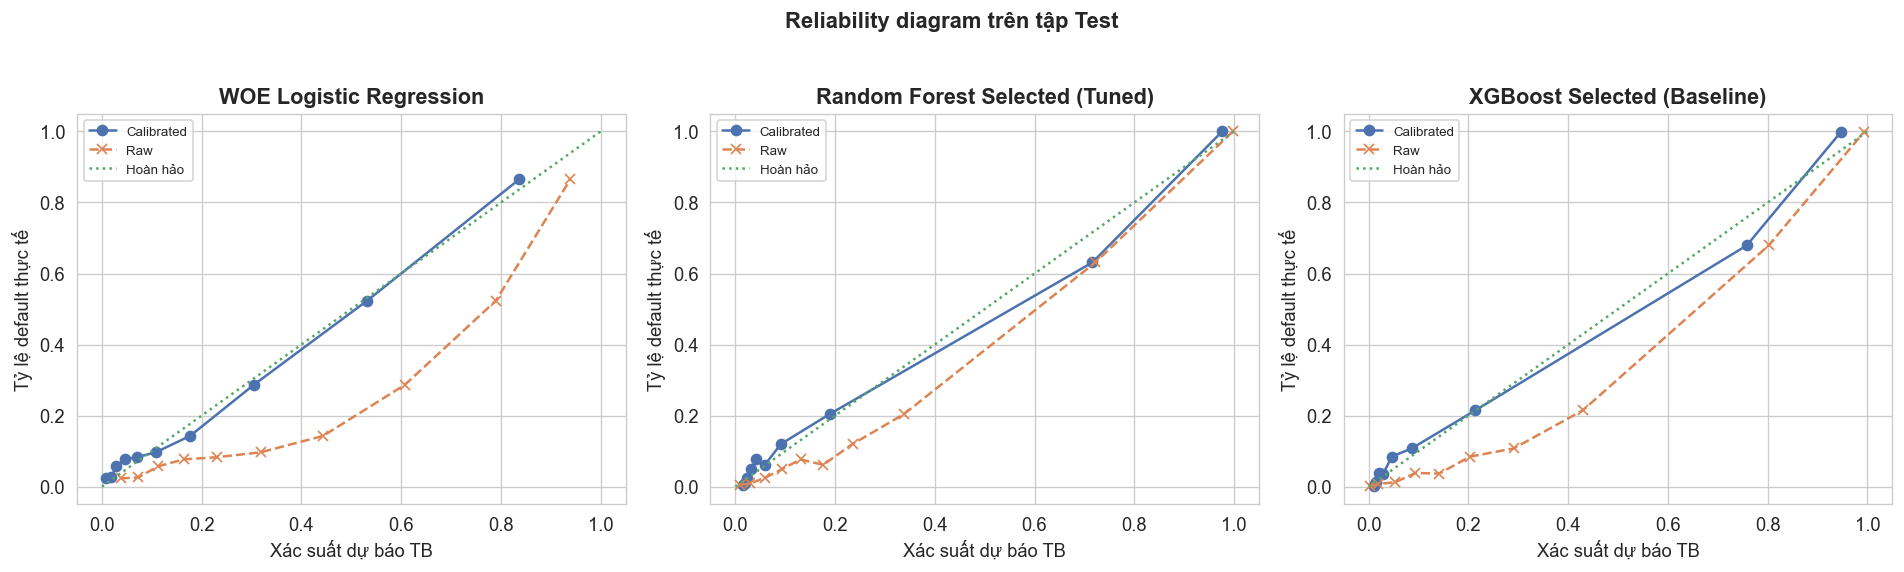

In [47]:
from sklearn.calibration import CalibratedClassifierCV, calibration_curve
from sklearn.frozen import FrozenEstimator

calibration_method = {name: 'sigmoid' for name in candidate_models}
calibrated_models = {}
for name, model in candidate_models.items():
    calibrator = CalibratedClassifierCV(
        estimator=FrozenEstimator(model),
        method=calibration_method[name]
    )
    calibrator.fit(X_val, y_val)
    calibrated_models[name] = calibrator

# So sánh chất lượng xác suất raw vs calibrated trên test
calibration_rows = []
test_raw_prob = {}
test_cal_prob = {}
for name, model in candidate_models.items():
    raw = model.predict_proba(X_test)[:,1]
    cal = calibrated_models[name].predict_proba(X_test)[:,1]
    test_raw_prob[name] = raw
    test_cal_prob[name] = cal
    calibration_rows.extend([
        {'Model':name,'Phiên bản':'Raw','ROC-AUC':roc_auc_score(y_test,raw),
         'Brier':brier_score_loss(y_test,raw),'LogLoss':log_loss(y_test,raw)},
        {'Model':name,'Phiên bản':'Calibrated','ROC-AUC':roc_auc_score(y_test,cal),
         'Brier':brier_score_loss(y_test,cal),'LogLoss':log_loss(y_test,cal)}
    ])
calibration_comparison = pd.DataFrame(calibration_rows)
display(calibration_comparison.style.format({'ROC-AUC':'{:.4f}','Brier':'{:.4f}','LogLoss':'{:.4f}'}))

fig, axes = plt.subplots(1,3,figsize=(16,4.6))
for ax,(name,p) in zip(axes,test_cal_prob.items()):
    obs,pred = calibration_curve(y_test,p,n_bins=10,strategy='quantile')
    ax.plot(pred,obs,marker='o',label='Calibrated')
    raw_obs,raw_pred = calibration_curve(y_test,test_raw_prob[name],n_bins=10,strategy='quantile')
    ax.plot(raw_pred,raw_obs,marker='x',linestyle='--',label='Raw')
    ax.plot([0,1],[0,1],linestyle=':',label='Hoàn hảo')
    ax.set_title(name); ax.set_xlabel('Xác suất dự báo TB'); ax.set_ylabel('Tỷ lệ default thực tế')
    ax.legend(fontsize=8)
plt.suptitle('Reliability diagram trên tập Test',y=1.03,fontweight='bold')
plt.tight_layout(); plt.show()

### Nhận xét calibration

Sigmoid calibration cải thiện chất lượng xác suất của cả ba mô hình:

- WOE Logistic: Brier giảm từ `0,1367` xuống `0,1013`; LogLoss giảm từ `0,4284` xuống `0,3392`.
- Random Forest selected: Brier giảm từ `0,0678` xuống `0,0625`; LogLoss giảm từ `0,2395` xuống `0,2241`.
- XGBoost selected: Brier giảm từ `0,0719` xuống `0,0588`; LogLoss giảm từ `0,2460` xuống `0,2126`.

ROC-AUC hầu như không đổi vì calibration chủ yếu điều chỉnh mức xác suất, không thay đổi đáng kể thứ tự xếp hạng. XGBoost có Brier thấp nhất sau calibration, nhưng vẫn cần đọc cùng Hosmer–Lemeshow và reliability diagram trước khi coi xác suất là PD.

## Bước 14: Kiểm định độ khớp xác suất

### Hosmer–Lemeshow

Xác suất được chia thành 10 nhóm theo quantile. Giả thuyết không: số default quan sát phù hợp với số kỳ vọng từ mô hình. `p-value > 0,05` nghĩa là chưa có bằng chứng bác bỏ độ khớp; tuy nhiên không đồng nghĩa mô hình chắc chắn được calibration hoàn hảo.

### Kiểm định nhị thức theo nhóm

Trong từng nhóm xác suất, kiểm định hai phía so sánh số default quan sát với xác suất trung bình dự báo. Đây là chẩn đoán bổ sung; khi đọc nhiều nhóm cần lưu ý vấn đề multiple testing.

In [48]:
from scipy.stats import chi2, binomtest

def calibration_bin_table(y_true, prob, groups=10):
    d = pd.DataFrame({'y':np.asarray(y_true,dtype=int),'p':np.asarray(prob,dtype=float)})
    d['group'] = pd.qcut(d['p'].rank(method='first'), q=groups, labels=False, duplicates='drop')
    tab = d.groupby('group',observed=True).agg(
        N=('y','size'), Default_observed=('y','sum'), Probability_mean=('p','mean')
    ).reset_index()
    tab['Default_expected'] = tab['N'] * tab['Probability_mean']
    tab['Bad_rate_observed'] = tab['Default_observed'] / tab['N']
    tab['Binomial_pvalue'] = [
        binomtest(int(o),int(n),p=float(np.clip(p,1e-9,1-1e-9))).pvalue
        for o,n,p in zip(tab['Default_observed'],tab['N'],tab['Probability_mean'])
    ]
    return tab

def hosmer_lemeshow_test(y_true, prob, groups=10):
    tab = calibration_bin_table(y_true,prob,groups)
    n=tab['N'].to_numpy(float); o=tab['Default_observed'].to_numpy(float); e=tab['Default_expected'].to_numpy(float)
    denom = e * (1 - e/n)
    stat = np.sum((o-e)**2 / np.clip(denom,1e-9,None))
    dof = max(len(tab)-2,1)
    pvalue = chi2.sf(stat,dof)
    return stat,dof,pvalue,tab

hl_rows=[]
hl_details={}
for name,p in test_cal_prob.items():
    stat,dof,pv,tab=hosmer_lemeshow_test(y_test,p,10)
    hl_rows.append({'Model':name,'HL statistic':stat,'df':dof,'p-value':pv,
                    'Kết luận 5%':'Chưa bác bỏ độ khớp' if pv>=0.05 else 'Bác bỏ độ khớp'})
    hl_details[name]=tab
hl_summary=pd.DataFrame(hl_rows).sort_values('p-value',ascending=False)
display(hl_summary.style.format({'HL statistic':'{:.3f}','p-value':'{:.3e}'}))

# Bảng chi tiết của mô hình có Brier calibrated thấp nhất
best_cal_name = (calibration_comparison.query("`Phiên bản` == 'Calibrated'")
                 .sort_values('Brier').iloc[0]['Model'])
print('Mô hình có Brier calibrated thấp nhất:',best_cal_name)
display(hl_details[best_cal_name].style.format({
    'Probability_mean':'{:.4f}','Default_expected':'{:.2f}',
    'Bad_rate_observed':'{:.4f}','Binomial_pvalue':'{:.4f}'
}))

,Model,HL statistic,df,p-value,Kết luận 5%
0,WOE Logistic Regression,62.939,8,1.232e-10,Bác bỏ độ khớp
1,Random Forest Selected (Tuned),81.405,8,2.548e-14,Bác bỏ độ khớp
2,XGBoost Selected (Baseline),99.960,8,4.350e-18,Bác bỏ độ khớp


Mô hình có Brier calibrated thấp nhất: XGBoost Selected (Baseline)


,group,N,Default_observed,Probability_mean,Default_expected,Bad_rate_observed,Binomial_pvalue
0,0,652,1,0.0106,6.90,0.0015,0.0188
1,1,651,5,0.0119,7.78,0.0077,0.4661
2,2,652,8,0.0153,10.00,0.0123,0.6334
3,3,651,25,0.0207,13.50,0.0384,0.0035
4,4,652,24,0.0294,19.17,0.0368,0.2462
5,5,651,55,0.0462,30.07,0.0845,0.0000
6,6,651,70,0.0861,56.05,0.1075,0.0588
7,7,652,140,0.2137,139.35,0.2147,0.9619
8,8,651,442,0.7579,493.38,0.6790,0.0000
9,9,652,651,0.9467,617.26,0.9985,0.0000


### Nhận xét kiểm định độ khớp

Hosmer–Lemeshow bác bỏ độ khớp của cả ba mô hình ở mức 5%:

- WOE Logistic: `p ≈ 1,23×10⁻¹⁰`;
- Random Forest selected: `p ≈ 2,55×10⁻¹⁴`;
- XGBoost selected: `p ≈ 9,05×10⁻¹⁸`.

Calibration đã cải thiện Brier và LogLoss nhưng vẫn còn chênh lệch có hệ thống giữa xác suất dự báo và bad rate quan sát. Vì vậy, đầu ra hiện tại phù hợp để sử dụng như **calibrated risk score**, chưa nên coi là PD chính thức cho pricing, ECL hoặc limit setting.

Hosmer–Lemeshow nhạy với cỡ mẫu lớn, nên kết luận cần kết hợp thêm reliability diagram, calibration intercept/slope và backtest out-of-time theo vintage.

# F. Đánh giá cuối cùng và khuyến nghị triển khai

## Bước 15: Đánh giá chi tiết ba mô hình sau calibration trên Test

Tập Test không tham gia fit mô hình, tuning, calibration hoặc chọn threshold. Các chỉ tiêu tại ngưỡng 0,5 dưới đây là kết quả đánh giá ngoài mẫu cuối cùng, gồm Classification Report và Confusion Matrix của từng mô hình.

MÔ HÌNH CALIBRATED: WOE Logistic Regression
                precision    recall  f1-score   support

Trả nợ tốt (0)     0.8873    0.9523    0.9187      5094
     Vỡ nợ (1)     0.7681    0.5665    0.6521      1421

      accuracy                         0.8682      6515
     macro avg     0.8277    0.7594    0.7854      6515
  weighted avg     0.8613    0.8682    0.8605      6515

Confusion matrix [[TN, FP], [FN, TP]]:
[[4851  243]
 [ 616  805]]
MÔ HÌNH CALIBRATED: Random Forest Selected (Tuned)
                precision    recall  f1-score   support

Trả nợ tốt (0)     0.9247    0.9817    0.9524      5094
     Vỡ nợ (1)     0.9160    0.7136    0.8022      1421

      accuracy                         0.9233      6515
     macro avg     0.9204    0.8477    0.8773      6515
  weighted avg     0.9228    0.9233    0.9196      6515

Confusion matrix [[TN, FP], [FN, TP]]:
[[5001   93]
 [ 407 1014]]
MÔ HÌNH CALIBRATED: XGBoost Selected (Baseline)
                precision    recall  f1-score  

,Model,Accuracy,Precision,Recall,F1-score,ROC-AUC,Brier,TN,FP,FN,TP
0,XGBoost Selected (Baseline),0.9280,0.8987,0.7551,0.8207,0.9434,0.0590,4973,121,348,1073
1,Random Forest Selected (Tuned),0.9233,0.9160,0.7136,0.8022,0.9286,0.0625,5001,93,407,1014
2,WOE Logistic Regression,0.8682,0.7681,0.5665,0.6521,0.8700,0.1013,4851,243,616,805


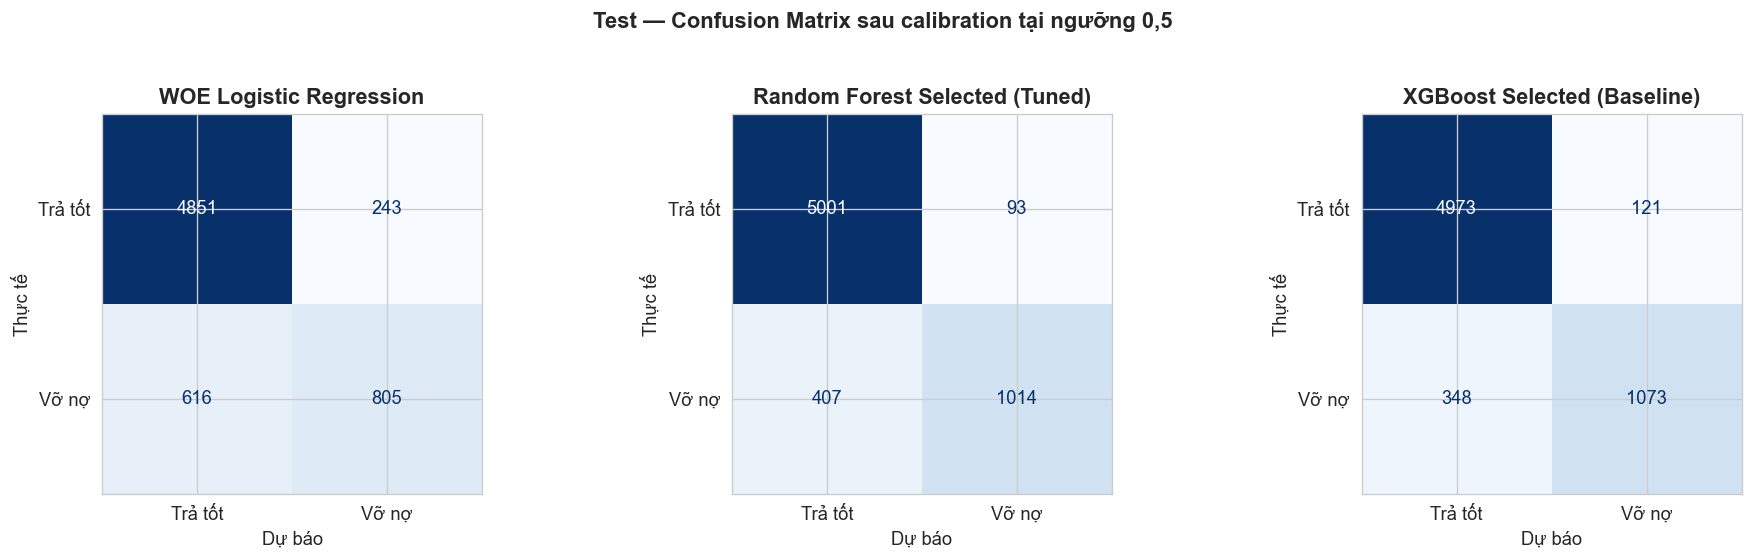

In [49]:
final_rows=[]
final_predictions={}
for name,p in test_cal_prob.items():
    pred=(p>=0.5).astype(int)
    cm=confusion_matrix(y_test,pred)
    final_predictions[name]=pred
    final_rows.append({
        'Model':name,'Accuracy':accuracy_score(y_test,pred),
        'Precision':precision_score(y_test,pred,zero_division=0),
        'Recall':recall_score(y_test,pred,zero_division=0),
        'F1-score':f1_score(y_test,pred,zero_division=0),
        'ROC-AUC':roc_auc_score(y_test,p),'Brier':brier_score_loss(y_test,p),
        'TN':cm[0,0],'FP':cm[0,1],'FN':cm[1,0],'TP':cm[1,1]
    })
    print('='*85)
    print('MÔ HÌNH CALIBRATED:',name)
    print(classification_report(y_test,pred,target_names=['Trả nợ tốt (0)','Vỡ nợ (1)'],digits=4,zero_division=0))
    print('Confusion matrix [[TN, FP], [FN, TP]]:')
    print(cm)

final_comparison=pd.DataFrame(final_rows).sort_values('ROC-AUC',ascending=False).reset_index(drop=True)
display(final_comparison.style.format({
    'Accuracy':'{:.4f}','Precision':'{:.4f}','Recall':'{:.4f}',
    'F1-score':'{:.4f}','ROC-AUC':'{:.4f}','Brier':'{:.4f}'
}))

fig,axes=plt.subplots(1,3,figsize=(16,4.5))
for ax,(name,pred) in zip(axes,final_predictions.items()):
    ConfusionMatrixDisplay(confusion_matrix(y_test,pred),display_labels=['Trả tốt','Vỡ nợ']).plot(
        ax=ax,cmap='Blues',colorbar=False,values_format='d')
    ax.set_title(name); ax.set_xlabel('Dự báo'); ax.set_ylabel('Thực tế')
plt.suptitle('Test — Confusion Matrix sau calibration tại ngưỡng 0,5',y=1.03,fontweight='bold')
plt.tight_layout(); plt.show()

### Nhận xét kết quả Test sau calibration

- **XGBoost selected (baseline)** là mô hình tốt nhất tổng thể: ROC-AUC `0,9434`, Brier `0,0588`, Recall `0,7502` và F1 `0,8137`. Mô hình phát hiện đúng 1.073/1.421 khách hàng default, bỏ sót 348 trường hợp và cảnh báo nhầm 121 khách hàng tốt.
- **Random Forest selected (tuned)** có Precision cao nhất `0,9160`, chỉ cảnh báo nhầm 93 khách hàng tốt, nhưng Recall thấp hơn ở mức `0,7136`, tương ứng bỏ sót 407 trường hợp default.
- **WOE Logistic** có tính giải thích cao nhưng hiệu quả thấp hơn: ROC-AUC `0,8700`, Brier `0,1013` và Recall `0,5665`.

XGBoost được chọn làm champion cho ranking và sàng lọc rủi ro. Random Forest tuned được duy trì làm challenger khi ưu tiên hạn chế cảnh báo nhầm. WOE Logistic là baseline/scorecard đối chứng.

## Bước 16: ROC, Precision–Recall và lựa chọn threshold trên Validation

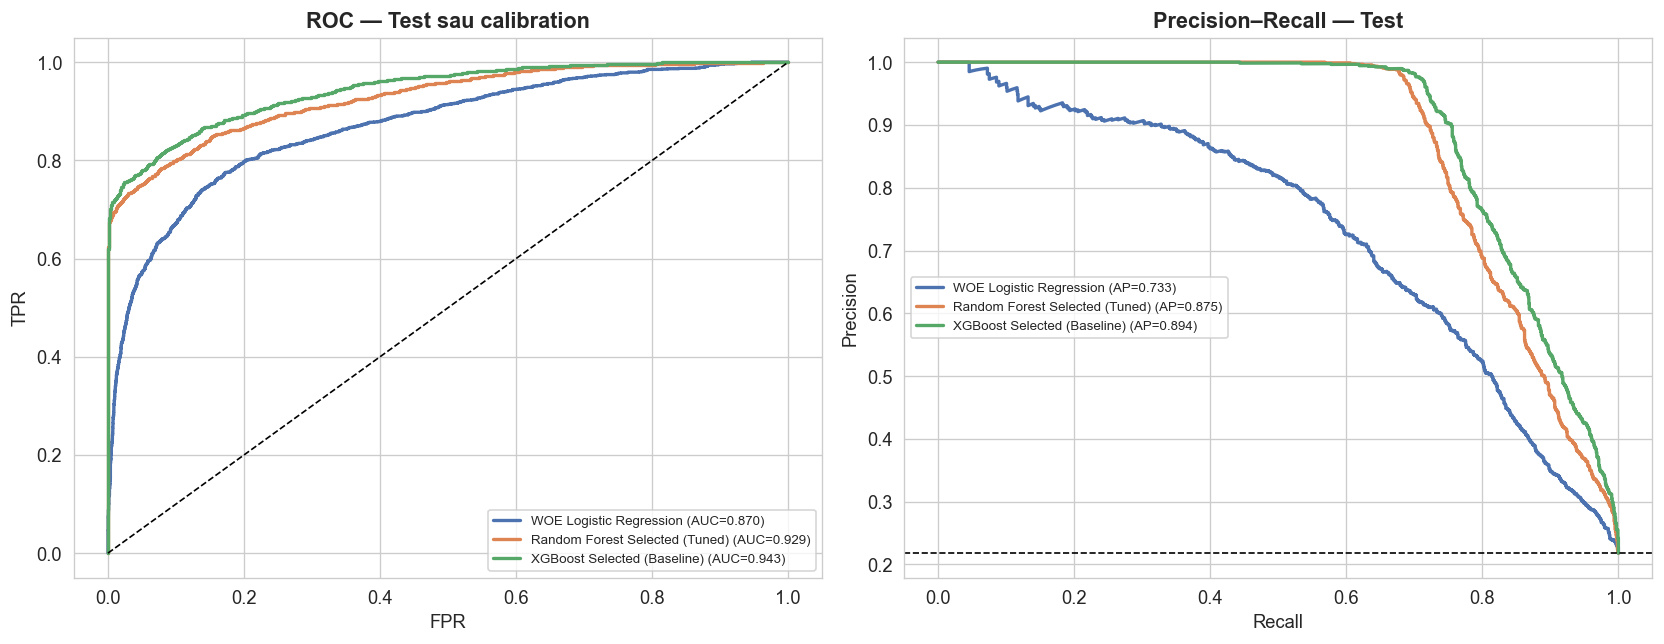

Champion theo validation ROC-AUC: XGBoost Selected (Baseline)
Threshold tối ưu F1 học từ validation: 0.76


,Phương án,Ngưỡng,Precision,Recall,F1-score,FP,FN,TP
0,Mặc định,0.500,0.8987,0.7551,0.8207,121,348,1073
1,Tối ưu F1 trên validation,0.760,0.9739,0.7094,0.8208,27,413,1008


In [50]:
from sklearn.metrics import roc_curve, precision_recall_curve, average_precision_score

fig,axes=plt.subplots(1,2,figsize=(14,5.5))
for name,p in test_cal_prob.items():
    fpr,tpr,_=roc_curve(y_test,p)
    axes[0].plot(fpr,tpr,lw=2,label=f'{name} (AUC={roc_auc_score(y_test,p):.3f})')
    precision,recall,_=precision_recall_curve(y_test,p)
    axes[1].plot(recall,precision,lw=2,label=f'{name} (AP={average_precision_score(y_test,p):.3f})')
axes[0].plot([0,1],[0,1],'k--',lw=1); axes[0].set_title('ROC — Test sau calibration')
axes[0].set_xlabel('FPR'); axes[0].set_ylabel('TPR'); axes[0].legend(fontsize=8)
axes[1].axhline(y_test.mean(),color='k',ls='--',lw=1); axes[1].set_title('Precision–Recall — Test')
axes[1].set_xlabel('Recall'); axes[1].set_ylabel('Precision'); axes[1].legend(fontsize=8)
plt.tight_layout(); plt.show()

# Champion theo ROC-AUC validation; threshold được chọn bằng F1 trên validation calibrated
champion_name=final_validation_comparison.sort_values('ROC-AUC',ascending=False).iloc[0]['Model']
champion_cal=calibrated_models[champion_name]
p_val_champion=champion_cal.predict_proba(X_val)[:,1]
p_test_champion=champion_cal.predict_proba(X_test)[:,1]
thresholds=np.linspace(0.01,0.99,99)
f1_values=np.array([f1_score(y_val,(p_val_champion>=t).astype(int),zero_division=0) for t in thresholds])
best_threshold=float(thresholds[f1_values.argmax()])

threshold_rows=[]
for label,t in [('Mặc định',0.5),('Tối ưu F1 trên validation',best_threshold)]:
    pred=(p_test_champion>=t).astype(int); cm=confusion_matrix(y_test,pred)
    threshold_rows.append({
        'Phương án':label,'Ngưỡng':t,
        'Precision':precision_score(y_test,pred,zero_division=0),
        'Recall':recall_score(y_test,pred,zero_division=0),
        'F1-score':f1_score(y_test,pred,zero_division=0),
        'FP':cm[0,1],'FN':cm[1,0],'TP':cm[1,1]
    })
threshold_result=pd.DataFrame(threshold_rows)
print('Champion theo validation ROC-AUC:',champion_name)
print('Threshold tối ưu F1 học từ validation:',round(best_threshold,3))
display(threshold_result.style.format({'Ngưỡng':'{:.3f}','Precision':'{:.4f}','Recall':'{:.4f}','F1-score':'{:.4f}'}))

### Nhận xét lựa chọn threshold

Threshold tối ưu F1 được học trên Validation là `0,76`. Khi áp dụng lên Test:

- Ngưỡng `0,50`: Precision `0,8987`, Recall `0,7551`, F1 `0,8207`, FP = 121 và FN = 348.
- Ngưỡng `0,73`: Precision tăng lên `0,9739`, FP giảm còn 27 và F1 tăng nhẹ lên `0,8208`; đổi lại Recall giảm còn `0,7094` và FN tăng lên 413.

Do đó, ngưỡng 0,76 phù hợp khi chi phí cảnh báo nhầm hoặc năng lực thẩm định là ràng buộc chính. Nếu ưu tiên hạn chế tổn thất tín dụng, ngân hàng cần cân nhắc threshold thấp hơn và gán chi phí cao hơn cho False Negative theo `EAD × LGD`.

## Bước 17: Đánh giá độ ổn định của điểm mô hình bằng PSI

In [51]:
score_train=champion_cal.predict_proba(X_train)[:,1]
score_val=champion_cal.predict_proba(X_val)[:,1]
score_test=champion_cal.predict_proba(X_test)[:,1]
score_psi_val=psi_numeric(pd.Series(score_train),pd.Series(score_val),bins=10)
score_psi_test=psi_numeric(pd.Series(score_train),pd.Series(score_test),bins=10)
score_psi=pd.DataFrame({
    'So sánh':['Train vs Validation','Train vs Test'],
    'Score PSI':[score_psi_val,score_psi_test]
})
score_psi['Mức độ']=pd.cut(score_psi['Score PSI'],[-np.inf,0.10,0.25,np.inf],
                           labels=['Ổn định','Theo dõi','Dịch chuyển đáng kể'],right=False)
display(score_psi.style.format({'Score PSI':'{:.4f}'}))

,So sánh,Score PSI,Mức độ
0,Train vs Validation,0.0020,Ổn định
1,Train vs Test,0.0019,Ổn định


**Nhận xét score PSI:** PSI của điểm champion là `0,0015` giữa Train–Validation và `0,0016` giữa Train–Test, cho thấy phân phối điểm ổn định trong phép chia mẫu hiện tại. Đây chỉ là kiểm tra nội bộ trên mẫu ngẫu nhiên; production cần theo dõi PSI theo tháng/vintage, điều tra khi PSI ≥ 0,10 và xem xét recalibration hoặc redevelopment khi PSI ≥ 0,25.

## Bước 18: Độ quan trọng biến và SHAP của XGBoost được lựa chọn

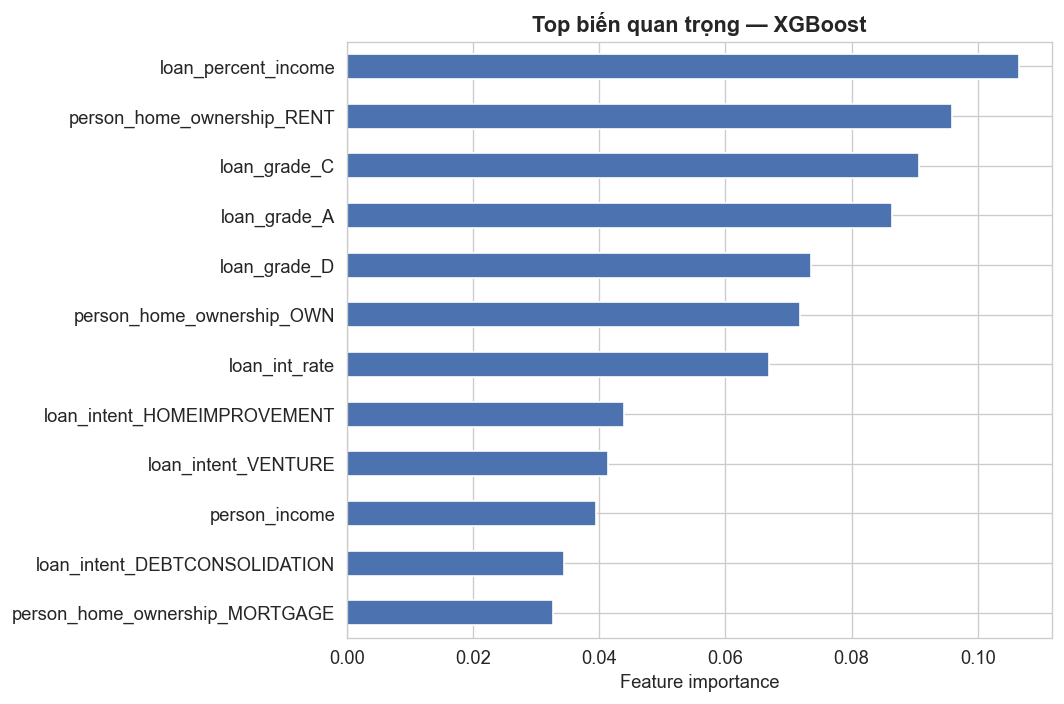

,Importance
loan_percent_income,0.1065
person_home_ownership_RENT,0.0959
loan_grade_C,0.0908
loan_grade_A,0.0864
loan_grade_D,0.0735
person_home_ownership_OWN,0.0717
loan_int_rate,0.0669
loan_intent_HOMEIMPROVEMENT,0.0439
loan_intent_VENTURE,0.0414
person_income,0.0394


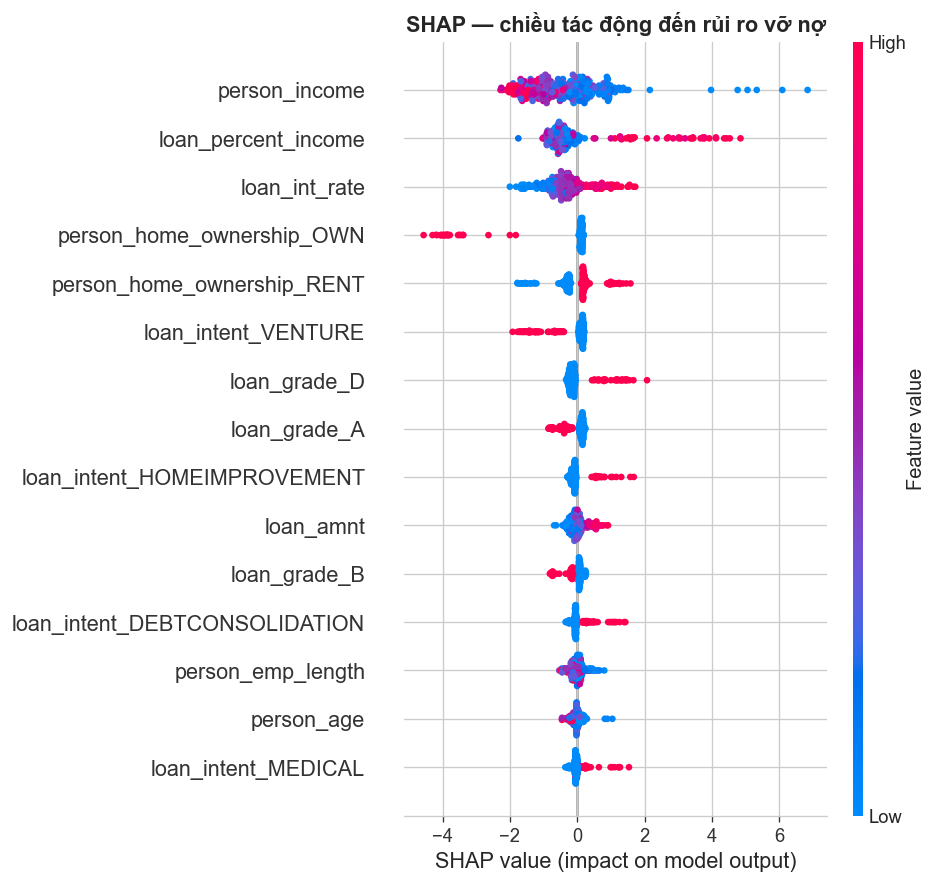

In [52]:
# Feature importance
xgb_prep=xgb_selected.named_steps['prep']
feature_names=xgb_prep.get_feature_names_out()
xgb_clf=xgb_selected.named_steps['clf']
importance=pd.Series(xgb_clf.feature_importances_,index=feature_names).sort_values(ascending=False)
plt.figure(figsize=(9,6)); importance.head(12).sort_values().plot(kind='barh')
plt.title('Top biến quan trọng — XGBoost'); plt.xlabel('Feature importance'); plt.tight_layout(); plt.show()
display(importance.head(15).rename('Importance').to_frame().style.format({'Importance':'{:.4f}'}))

# SHAP trên mẫu test để giảm thời gian và giữ biểu đồ dễ đọc
import shap
sample_n=min(300,len(X_test))
X_shap=X_test.sample(sample_n,random_state=RANDOM_STATE)
X_shap_trans=xgb_prep.transform(X_shap)
X_shap_trans=pd.DataFrame(X_shap_trans,columns=feature_names,index=X_shap.index)
explainer=shap.TreeExplainer(xgb_clf)
shap_values=explainer.shap_values(X_shap_trans)
shap.summary_plot(shap_values,X_shap_trans,show=False,max_display=15)
plt.title('SHAP — chiều tác động đến rủi ro vỡ nợ',fontweight='bold'); plt.tight_layout(); plt.show()

### Nguyên tắc diễn giải feature importance và SHAP

Feature importance cho biết mức độ mô hình sử dụng biến, còn SHAP cho biết cả mức độ và chiều tác động tại từng quan sát. Kết quả phải được đối chiếu với EDA, IV và hiểu biết nghiệp vụ.

Đặc biệt cần kiểm tra thời điểm hình thành của `loan_grade` và `loan_int_rate`. Nếu các biến này chỉ xuất hiện sau hoặc đồng thời với quyết định tín dụng, cần xây dựng thêm application challenger không sử dụng chúng để loại trừ leakage và vòng lặp chính sách.

### Nhận xét biến quan trọng

XGBoost tập trung mạnh vào `loan_grade`, `loan_percent_income`, tình trạng sở hữu nhà và `loan_int_rate`. Các biến one-hot của hạng C, D, A và nhóm thuê/sở hữu nhà nằm trong nhóm quan trọng nhất. Kết quả này nhất quán với EDA và IV, nhưng cũng củng cố yêu cầu kiểm tra thời điểm hình thành `loan_grade` và `loan_int_rate`.

Để tránh mô hình phụ thuộc vào kết quả của quy trình thẩm định hiện hữu, nên xây dựng thêm một **challenger không sử dụng `loan_grade` và `loan_int_rate`**. Nếu hiệu quả giảm không đáng kể, phiên bản không có hai biến này sẽ phù hợp hơn cho chấm điểm đầu vào và giảm rủi ro vòng lặp chính sách.

## Bước 19: Tổng hợp kết quả và khuyến nghị triển khai

Cell dưới đây sinh kết luận định lượng trực tiếp từ các bảng kết quả nhằm bảo đảm nhận xét luôn đồng bộ với code sau mỗi lần chạy lại.

In [53]:
print('BẢNG KẾT QUẢ TEST SAU CALIBRATION')
print(final_comparison.round(4).to_string(index=False))

print('\nKẾT QUẢ HOSMER–LEMESHOW')
print(hl_summary.to_string(
    index=False,
    formatters={
        'HL statistic': lambda x: f'{x:.4f}',
        'p-value': lambda x: f'{x:.3e}'
    }
))

print('\nPSI ĐIỂM CHAMPION')
print(score_psi.round(4).to_string(index=False))

print(f'\nRANDOM FOREST CONFIGURATION SELECTED: {rf_selection}')
print('BEST PARAMETERS — RANDOM FOREST SEARCH')
print(rf_search.best_params_)

print(f'\nXGBOOST CONFIGURATION SELECTED: {xgb_selection}')
print('BEST PARAMETERS — XGBOOST SEARCH')
print(xgb_search.best_params_)

test_champion = final_comparison.sort_values(
    ['ROC-AUC', 'Brier'],
    ascending=[False, True]
).iloc[0]

best_precision_model = final_comparison.sort_values(
    'Precision',
    ascending=False
).iloc[0]

print('\nKẾT LUẬN TỰ ĐỘNG')
print(
    f"- Champion theo ROC-AUC trên Test: {test_champion['Model']} "
    f"(ROC-AUC={test_champion['ROC-AUC']:.4f}, "
    f"Recall={test_champion['Recall']:.4f}, "
    f"F1={test_champion['F1-score']:.4f}, "
    f"Brier={test_champion['Brier']:.4f})."
)
print(
    f"- Mô hình có Precision cao nhất: {best_precision_model['Model']} "
    f"(Precision={best_precision_model['Precision']:.4f})."
)
print(
    f"- Champion được chọn trên Validation để lựa chọn threshold: {champion_name}; "
    f"threshold tối ưu F1 trên Validation={best_threshold:.3f}."
)
print(
    '- Tuning được thực hiện bằng cross-validation trên Train; '
    'calibration và threshold sử dụng Validation; Test chỉ dùng để báo cáo cuối.'
)

BẢNG KẾT QUẢ TEST SAU CALIBRATION
                         Model  Accuracy  Precision  Recall  F1-score  ROC-AUC  Brier   TN  FP  FN   TP
   XGBoost Selected (Baseline)    0.9280     0.8987  0.7551    0.8207   0.9434 0.0590 4973 121 348 1073
Random Forest Selected (Tuned)    0.9233     0.9160  0.7136    0.8022   0.9286 0.0625 5001  93 407 1014
       WOE Logistic Regression    0.8682     0.7681  0.5665    0.6521   0.8700 0.1013 4851 243 616  805

KẾT QUẢ HOSMER–LEMESHOW
                         Model HL statistic  df   p-value    Kết luận 5%
       WOE Logistic Regression      62.9389   8 1.232e-10 Bác bỏ độ khớp
Random Forest Selected (Tuned)      81.4055   8 2.548e-14 Bác bỏ độ khớp
   XGBoost Selected (Baseline)      99.9601   8 4.350e-18 Bác bỏ độ khớp

PSI ĐIỂM CHAMPION
            So sánh  Score PSI  Mức độ
Train vs Validation     0.0020 Ổn định
      Train vs Test     0.0019 Ổn định

RANDOM FOREST CONFIGURATION SELECTED: Tuned
BEST PARAMETERS — RANDOM FOREST SEARCH
{'clf__n_esti

## Kết luận và ba nhóm giải pháp ưu tiên cho ngân hàng

### Kết luận mô hình

XGBoost baseline được giữ lại sau bước so sánh trước–sau tuning vì có ROC-AUC Validation cao hơn bản tuned. Sau calibration, mô hình đạt ROC-AUC Test `0,9434`, Brier `0,0588`, Recall `0,7502` và F1 `0,8137`, nên được lựa chọn làm **champion cho ranking và sàng lọc rủi ro**.

Random Forest tuned đạt Precision cao nhất `0,9160`, phù hợp làm challenger trong luồng ưu tiên hạn chế cảnh báo nhầm khách hàng tốt. WOE Logistic được giữ làm baseline minh bạch và công cụ kiểm tra dấu, IV và tính hợp lý nghiệp vụ.

Do Hosmer–Lemeshow vẫn bác bỏ độ khớp, xác suất hiện tại chỉ nên được gọi là **calibrated risk score**, chưa phải PD chính thức.

### Khuyến nghị cho nhìn ngân hàng

#### A. Về triển khai mô hình vào quy trình thẩm định và quản lý sau vay

**1. Đề xuất luồng ra quyết định**

Không dùng một threshold duy nhất để tự động phê duyệt/từ chối. Nên thiết kế các dải điểm:

| Nhóm điểm | Hành động đề xuất |
|---|---|
| Rủi ro thấp | Fast-track nếu vượt toàn bộ hard rule, fraud check và bureau check |
| Rủi ro trung bình | Xác minh thu nhập, nghĩa vụ nợ, lịch sử trả nợ và mục đích vay |
| Rủi ro cao | Chuyển thẩm định thủ công, cân nhắc giảm hạn mức/rút ngắn kỳ hạn/yêu cầu chứng từ bổ sung |
| Rủi ro rất cao | Chỉ xem xét khi có yếu tố giảm thiểu rủi ro rõ ràng; không tự động từ chối chỉ dựa trên mô hình |

Ngưỡng 0,50 bắt được nhiều default hơn nhưng tạo 133 cảnh báo nhầm. Ngưỡng 0,73 giảm cảnh báo nhầm xuống 32 nhưng bỏ sót thêm 61 default so với ngưỡng 0,50. Threshold production phải được tối ưu theo Expected Loss, năng lực thẩm định và khẩu vị rủi ro.
Ngoài ra, **Áp dụng ngưỡng khác nhau theo phân khúc sản phẩm** như: với khoản vay tín chấp giá trị nhỏ, có thể dùng ngưỡng cao (0,73) ưu tiên precision để không bỏ lỡ khách tốt; với khoản vay giá trị lớn hoặc kỳ hạn dài, hạ ngưỡng xuống ~0,40–0,50 để tăng recall, chấp nhận từ chối nhầm nhiều hơn để bảo vệ vốn.

**2. Quản lý sau giải ngân và cảnh báo sớm đối với khách hàng rủi ro**

Bên cạnh việc hỗ trợ cấp tín dụng, điểm rủi ro có thể được sử dụng để phân nhóm khách hàng cần theo dõi sau giải ngân. Giải pháp này giúp ngân hàng chủ động phòng ngừa nợ xấu thay vì chỉ xử lý khi khách hàng đã quá hạn.

Đối với các khách hàng có risk score cao nhưng vẫn được phê duyệt, ngân hàng nên:

- Đưa vào watchlist trong 3–6 tháng đầu sau giải ngân;
- Theo dõi first-payment default và tình trạng thanh toán các kỳ đầu;
- Theo dõi suy giảm dòng tiền vào tài khoản;
- Kiểm tra phát sinh khoản vay mới hoặc dư nợ tăng mạnh trên CIC;
- Tạm dừng chiến dịch tăng hạn mức hoặc cấp thêm tín dụng không có bảo đảm;
- Gửi nhắc nợ trước ngày đến hạn và liên hệ sớm khi xuất hiện dấu hiệu khó khăn.

Có thể phân nhóm hành động theo tình trạng khách hàng:

| Tình trạng | Hành động đề xuất |
|---|---|
| Score cao nhưng chưa quá hạn | Theo dõi watchlist, không tăng hạn mức, nhắc nợ chủ động |
| Chậm thanh toán lần đầu | Liên hệ sớm để xác định nguyên nhân và khả năng thanh toán |
| Suy giảm thu nhập hoặc dòng tiền | Đánh giá phương án hỗ trợ hoặc cơ cấu theo chính sách |
| Quá hạn kéo dài, có dấu hiệu né tránh | Chuyển sang luồng thu hồi nợ tăng cường |

Đối với khách hàng có score thấp và lịch sử thanh toán tốt, ngân hàng có thể ưu tiên các chương trình pre-approved hoặc cross-sell. Tuy nhiên, mọi đề xuất cấp thêm tín dụng vẫn phải được kiểm tra lại CIC và khả năng trả nợ tại thời điểm đề xuất.

Mô hình hiện tại là application/default model nên chỉ được sử dụng như một tín hiệu bổ sung trong quản lý sau giải ngân. Trong dài hạn, ngân hàng cần phát triển riêng behavioral score và collection score dựa trên dữ liệu thanh toán, DPD, dòng tiền và hành vi sử dụng sản phẩm.

**Giải pháp ưu tiên:** áp dụng risk score để thiết lập watchlist và cơ chế nhắc nợ sớm cho khách hàng rủi ro cao trong các tháng đầu sau giải ngân.

---

#### B. Về chính sách tín dụng theo nhóm khách hàng** (dựa trên phát hiện EDA + SHAP)

**1. Trần tỷ lệ vay/thu nhập**: nhóm vỡ nợ có trung vị loan_percent_income = 0,24 so với 0,13 ở nhóm trả tốt. Đề xuất đặt **ngưỡng cảnh báo khi tỷ lệ vay/thu nhập > 0,20** và yêu cầu thẩm định bổ sung (chứng minh thu nhập, tài sản đảm bảo) với các hồ sơ vượt ngưỡng.

**2. Siết điều kiện với hạng tín dụng thấp**: tỷ lệ vỡ nợ nhảy từ 20,7% (hạng C) lên 59,0% (hạng D). Đề xuất **rà soát riêng chính sách phê duyệt từ hạng D trở xuống**: tăng lãi suất bù rủi ro, giảm hạn mức, hoặc yêu cầu tài sản đảm bảo.

**3. Nhóm thuê nhà**: tỷ lệ vỡ nợ ~31% (gấp 4–5 lần nhóm sở hữu nhà). Đề xuất **thêm biến tình trạng nhà ở vào scorecard** và cân nhắc chính sách hạn mức thận trọng hơn cho khách thuê nhà chưa có tài sản đảm bảo.

**4. Mục đích vay rủi ro cao**: vay trả nợ (DEBTCONSOLIDATION, 28,6%) và y tế (MEDICAL, 26,7%) có tỷ lệ vỡ nợ cao nhất. Đề xuất **giám sát chặt hơn hai nhóm mục đích này** và kiểm tra kỹ dòng tiền trả nợ

---

#### C. Về vận hành - giám sát và tối ưu mô hình (MLOps/Model Risk)
**1. Hành động đối với WOE Logistic**

- Re-bin hoặc thử loại `cb_person_default_on_file` vì hệ số sai dấu và không có ý nghĩa thống kê.
- Rà soát `person_age` và `loan_int_rate` do p-value trên 5% trong mô hình suy luận.
- Kiểm tra tính đơn điệu của bad rate trong từng bin và gộp bin có ít quan sát.
- So sánh mô hình đầy đủ với mô hình loại `loan_grade`/`loan_int_rate` để kiểm tra leakage và tính vòng tròn.
- Nếu phát triển scorecard chính thức, bổ sung scaling điểm, PDO, base score và odds chuẩn.

**2. Kế hoạch cải thiện calibration**

- Dùng mẫu calibration out-of-time thay vì chỉ chia ngẫu nhiên.
- Đánh giá thêm calibration intercept và slope; so sánh sigmoid, isotonic và beta calibration.
- Cân nhắc calibrator riêng theo sản phẩm/kênh/segment nếu có khác biệt cấu trúc.
- Backtest PD theo decile và vintage; theo dõi tỷ lệ default quan sát so với kỳ vọng.
- Không dùng class weight/scale_pos_weight như giải pháp duy nhất nếu mục tiêu cuối là xác suất PD; có thể huấn luyện mô hình ranking rồi calibration trên mẫu phản ánh đúng prevalence production.

**3. Dashboard giám sát production**

Dashboard Risk/Model Monitoring nên theo dõi tối thiểu:

- AUC/KS, Precision, Recall, FPR, FNR theo tháng và vintage;
- Brier score, LogLoss, calibration slope/intercept và observed/expected default theo decile;
- PSI từng biến và score PSI, tỷ lệ missing, tỷ lệ category mới;
- approval rate, manual review rate, override rate và bad rate sau override;
- kết quả theo sản phẩm, kênh bán, mục đích vay, khu vực và nhóm khách hàng;
- cảnh báo khi PSI ≥ 0,10, AUC suy giảm vượt ngưỡng hoặc observed default lệch đáng kể so với expected default.

### Hạn chế

Dữ liệu hiện tại là dữ liệu cắt ngang, không có thời điểm quan sát, mã khoản vay/khách hàng, DPD, EAD, LGD, dòng tiền và thông tin kinh tế vĩ mô. Vì vậy, bài làm phù hợp để minh họa quy trình phát triển mô hình, nhưng chưa đủ điều kiện triển khai như một hệ thống phê duyệt hoặc ước lượng PD chính thức. Bước tiếp theo bắt buộc là kiểm định ngoài thời gian, model validation độc lập, fairness testing, stress testing và phê duyệt bởi Risk/Compliance